# Direct detection with trans-stilbene 

Calculating electron recoil scattering rate in trans-stilbene, using the LCAO wavefunctions for the ground and excited states derived in arXiv:2103.08601. The $\langle f_s^2 | n \ell m \rangle$ coefficients used in this notebook are taken from 2021 data, of $f_s^2(\vec q)$ tabulated on a spherical grid of $\vec q$ points. Enough data was available to reconstruct the $s_1$, $s_2$, $s_5$ and $s_8$ transition form factors using a discrete spherical harmonic transformation. 

## Tabulated Form Factors

Excited states $s_3$ and $s_4$ are not included here, even though they contribute non-negligibly to the rate. The $s_{2,5,8}$ transitions $f_s^2(\vec q)$ were evaluated at polar angles $\theta = 30^\circ, 45^\circ, 60^\circ, 75^\circ, 90^\circ$ on a five-degree grid of $\phi = 0, 5^\circ, 10^\circ, \ldots, 175^\circ$. The form factors vanish at $\theta = 0$, and they are symmetric under $180^\circ$ rotations about the $z$ axis, and under central inversion symmetry $\vec q \rightarrow - \vec q$. The $\langle f_s^2 | n \ell m \rangle$ coefficients were calculated by interpolating $f_s^2(\vec q)$ in $\theta$ to generate better coverage in the polar angle, then performing a discrete spherical harmonic transformation at each fixed value of $|\vec q|$, to extract a 1d function of $q = |\vec q|$ for each $(\ell m)$ mode, $\langle f_s^2 | \ell m \rangle$. The $s_{3,4}$ transitions are not included simply because they were only tabulated with detail at $\theta = 90^\circ$. As a result, the $s_{2,5,8}$ transitions here should be thought of as a placeholder for the systematic error in neglecting the higher excited states. 

From arXiv:2103.08601, the $s_1$ transition always provides the dominant component of the scattering rate, at least for DM masses $m_\chi \leq 100$ MeV. The 2021 data tabulated $f_s^2(\vec q)$ on a five-degree angular grid in $\theta = 5^\circ, 10^\circ, \ldots, 90^\circ$ and in $\phi$. 

The 2021 data was produced over approximately two weeks of non-consecutive cluster time. In the future, we expect it to be much faster to generate $f_s^2(\vec q)$ from standard physical chemistry codes, using gaussian-type orbital basis functions (GTO). The analysis pipeline would calculate $f_s(\vec q)$ from the ground state and final state electronic wavefunctions in the GTO basis, using some analytic results to simplify the integrals, to tabulate $f_s(\vec q)$ on a spherical grid of points. Then, the coefficients $\langle f_s^2 | n \ell m \rangle$ can be found very quickly by performing discrete transforms on the squared $f_s(\vec q)$ data. 

## Crystal Form Factors 

The unit cell of the crystal contains four molecules of trans-stilbene, rotated relative to the crystal $z$ axis (defined in 2103.08601):
$$f_{crys}^2(\vec q) = \sum_{i = 1..4} \mathcal R_i \cdot f_s^2(\vec q),$$
for four rotation operators $\mathcal R_i$ acting on the molecular form factors. 
Aria has applied these rotations to the molecular $\langle f_s^2 | n \ell m \rangle$ coefficients, adding the results together into a single set of $\langle f_{crys}^2 | n \ell m \rangle$, the momentum form factor for one unit cell of the crystal. The total scattering rate, for a detector of mass $M_T$, is proportional to the number of unit cells: 
$$N_{\rm cell} = N_A \frac{M_T}{4 \cdot m_{mol}} = N_A \frac{M_T}{721.0\ \rm g}, $$
where $N_A = 6.022 \cdot 10^{23}$ is Avogadro's number. 


In [ ]:
# Load numerical, plotting, rotation, astronomy, and VSDM utilities.
# These are needed to rotate crystal form factors, compute the time-dependent dark matter wind direction, 
#and plot modulation curves.

import math
import numpy as np
# import numba
import scipy.special as spf
import scipy.interpolate as interp
# import vegas # numeric integration
# import gvar # gaussian variables; for vegas
import time
import quaternionic as qnc # For rotations
# import spherical #For Wigner D matrix
# import csv # file IO for projectFnlm
# import os.path
import h5py # database format for mathcalI arrays
# import importlib
from sympy.combinatorics import Permutation
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr

# Changing to false to avoid a warning about missing LaTeX packages - Martha
plt.rc('text', usetex=False)

#sys.path.insert(0,'../') #load the local version of vsdm

# Martha - cloned repos after import sys
sys.path.insert(0, '/Users/marthayousif/vsdm')
sys.path.insert(0, '/Users/marthayousif/earthspeed')

# Tests by Martha: 
# import os
# print(os.getcwd())
# print(os.listdir())
# print(os.listdir('../'))

import vsdm
from vsdm.units import *
from vsdm.utilities import *
# from vsdm import McalK

import datetime as dts #for calendar functions
from astropy.coordinates import SkyCoord, Galactic, ICRS
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import solar_system_ephemeris, EarthLocation
from astropy.coordinates import get_body_barycentric, get_body
from astropy.coordinates import CartesianRepresentation, CartesianDifferential

import earthspeed as ethp
from earthspeed import Windfinder

# Check for the latest version of vsdm and earthspeed, and test the Wigner rotation tools.
# PASS confirms the rotation/basis machinery is working.
diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)
print("earthspeed", ethp.__version__)

deg = np.pi/180
unisize = 3.5

testing 'spherical' and WignerG: PASS
vsdm 0.4.4
earthspeed 1.2


In [3]:
### Quaternion rotation
# finding the rotation that moves a 'z hat' unit vector to point towards (theta, phi)

def getQ(theta, phi):
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return qnc.array(qr, qi, qj, qk)


def ix_thetaphi(theta, phi):
    return thetaphilist.index((theta, phi))

# Construct the rotation from the crystal/cube coordinate system to the co-rotating lab frame for a chosen cube placement.
# First align the chosen up-facing face with +z, then rotate around +z so the selected side face points toward the CCD.

def getRcrl(Uvec, Fvec, gamma): 
    # U points up 
    # F points horizontally towards CCD
    # gamma is CCD poisition (on horizon) wrt north horizon
    Uhat = Uvec / np.linalg.norm(Uvec)
    zhat = np.array([0, 0, 1])
    nUvec = np.cross(Uhat, zhat) 
    if np.linalg.norm(nUvec) == 0:
        nUhat = np.array([1, 0, 0])
    else:
        nUhat = nUvec / np.linalg.norm(nUvec)
    alphaU = np.arccos(Uhat @ zhat)
    nU = qnc.array([0] + [qi for qi in nUhat])
    QrU = np.cos(0.5*alphaU) * qnc.array(1, 0, 0, 0) + np.sin(0.5*alphaU) * nU
    # act with qrU on U: returns zhat.
    # act with qrU on F:
    Fhat = Fvec / np.linalg.norm(Fvec)
    nF = qnc.array([0] + [qi for qi in Fhat])
    RuF = QrU * nF / QrU
    RuFhat = RuF.vector # just the imaginary part of RuF: a 3d vector
    # get azimuthal coordinate of RuF:
    is_one, thetaRuF, phiRuF = cart_to_sph(RuFhat)
    # difference between phiRuF and gamma: 
    alphaF = (gamma - phiRuF) % (2*np.pi) 
    # rotate RuF about +z axis to point towards CCD (at gamma):
    QrF = qnc.array(np.cos(0.5*alphaF), 0, 0, np.sin(0.5*alphaF))
    Qrcl = QrF * QrU
    return Qrcl

def rotateBy(qR, v):
    # rotate a vector v (or array of vectors) by rotation operator qR
    return qR * v / qR

def fRMS(R_list):
    # Compute the fractional RMS modulation amplitude of a rate curve.
    # This measures how strongly R(t) varies relative to its average.
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq / Rbar

def chi2norm(R_list):
    # Compute a normalized chi-square-like measure of how non-flat the rate curve is compared with its average.
    Rbar = np.mean(R_list) 
    Rt = np.array(R_list)
    diff_sq = (Rt - Rbar)**2
    root_mean_sq = np.sqrt(np.mean(diff_sq))
    return root_mean_sq**2 / Rbar
 

### Crystal Geometry: 

Using 2025 indexing data from Dane Johnson (MIT). The cubes are labeled numerically (1-6), and the individual faces are labeled with letters A, B, C. These labels are unrelated to the geometry of the crystal unit cell. 

In [4]:
"""Cube normal vectors: provided in (a, b, c) basis."""

#unit vectors or not?
lenA = 12.4057
lenB = 5.7411
lenC = 15.7978
angb = 111.8510 * np.pi/180

# (x, y, z) basis:
hatB = np.array([0, 0, 1]) # b = z
hatC = np.array([1, 0, 0]) # c = x
hatA = np.array([np.cos(angb), np.sin(angb), 0]) # a ~ y

vecA = lenA * hatA
vecB = lenB * hatB
vecC = lenC * hatC

# data from Dane:
cubeface = {} 
cubeface['1a'] = np.array([-1, -1, 6])
cubeface['1b'] = np.array([7, 0, -2])
cubeface['1c'] = np.array([1, 5, 5])

cubeface['2a'] = np.array([0, 0, 1])
cubeface['2b'] = np.array([8, -1, 3])
cubeface['2c'] = np.array([3, 6, 2])

cubeface['3a'] = np.array([-9, 0, 4])
cubeface['3b'] = np.array([0, 1, 7])
cubeface['3c'] = np.array([-1, 5, -3])

cubeface['4a'] = np.array([0, 0, 1])
cubeface['4b'] = np.array([5, 1, 3])
cubeface['4c'] = np.array([-3, 5, 4])

# changing (c,b) order to get right-handed systems:
cubeface['5a'] = np.array([0, 0, 1])
cubeface['5c'] = np.array([2, 0, 1])
cubeface['5b'] = np.array([1, -4, 0])

cubeface['6a'] = np.array([-1, 1, 8])
cubeface['6c'] = np.array([-9, -1, -3])
cubeface['6b'] = np.array([-2, 8, -3])

# convert each indexed cube face into a unit normal vector in the (x, y, z) basis
def getUvec(cface, unit=True):
    na, nb, nc = cface
    if unit:
        uvec = na * hatA + nb * hatB + nc * hatC # unit vectors
    else:
        uvec = na * vecA + nb * vecB + nc * vecC # vectors of different lengths
    uvec = uvec / np.linalg.norm(uvec) # normalize length to 1
    return uvec

# get the unit normal vectors and their spherical coordinates for each cube face
# later cells can use the face orientations to build possible cube rotations      
uvecs = {}
uhats = {}
for key,cface in cubeface.items():
    uvec = getUvec(cface, unit=True)
    uvecs[key] = uvec
    usph = vsdm.cart_to_sph(uvec)
    uhats[key] = (usph[1], usph[2]) # theta_u, phi_u
    print(key, uvecs[key], uhats[key])

#

1a [ 0.97783738 -0.14242889 -0.1534538 ] (1.7248588522494646, 6.138545441592046)
1b [-0.5782897   0.81583149  0.        ] (1.5707963267948966, 2.1874270700109912)
1c [0.67304688 0.1349866  0.72717709] (0.7565957172743824, 0.19793441136391038)
2a [1. 0. 0.] (1.5707963267948966, 0)
2b [ 0.00299598  0.9910483  -0.13347022] (1.7046660358403347, 1.56777329554715)
2c [0.13237982 0.41725108 0.89909795] (0.45309186177676364, 1.263574876915445)
3a [ 0.66056511 -0.75076876  0.        ] (1.5707963267948966, 5.433960204939333)
3b [0.98994949 0.         0.14142136] (1.4288992721907325, 0)
3c [-0.45906695 -0.16214487  0.87347958] (0.5084922185120431, 3.481120096534118)
4a [1. 0. 0.] (1.5707963267948966, 0)
4b [0.23331078 0.95058378 0.204833  ] (1.3645032364153873, 1.33011450794518)
4c [ 0.66650277 -0.36271348  0.65131636] (0.8614784079371993, 5.784802879593664)
5a [1. 0. 0.] (1.5707963267948966, 0)
5c [0.13641166 0.99065224 0.        ] (1.5707963267948966, 1.4339580222560437)
5b [-0.09027034  0.2251

This cell checks the geometry of each cube using the 3 measured face-normal unit vectors a, b, and c. It calculates the angles between each face pair using dot products; for an ideal cube, these angles would be close to 90 degrees.

The 'volume' is the scalar triple product '(uA x uB) · uC' which checks how well the 3 directions form an independent 3D basis. Values closer to 1 indicate tha the vectors are close to mutually perpendicular and form a strong 3D basis.

Later cells use the most cube-like cubes (2, 5, 6) based on this analysis.


In [6]:
# print("Cube angles assuming (a, b, c) vectors of length (12.4, 5.7, 15.8):")
print("Cube angles assuming (a, b, c) vectors of length (1, 1, 1):")
for ic in range(1, 7):
    uA = uvecs[str(ic)+'a']
    uB = uvecs[str(ic)+'b']
    uC = uvecs[str(ic)+'c']
    dAB = uA @ uB
    dAC = uA @ uC
    dBC = uB @ uC
    volume = (np.cross(uA, uB) @ uC)
    # print('{}:'.format(ic), dAB, dAC, dBC)
    thAB = np.arccos(dAB) * 180/np.pi
    thAC = np.arccos(dAC) * 180/np.pi
    thBC = np.arccos(dBC) * 180/np.pi
    print('{}.'.format(ic), 'vol: {:.3f}'.format(volume), 'AB: {:.1f}'.format(thAB), 'AC: {:.1f}'.format(thAC), 'BC: {:.1f}'.format(thBC))
    
#

Cube angles assuming (a, b, c) vectors of length (1, 1, 1):
1. vol: 0.616 AB: 133.0 AC: 58.2 BC: 106.2
2. vol: 0.947 AB: 89.8 AC: 82.4 BC: 72.9
3. vol: 0.713 AB: 49.2 AC: 100.5 BC: 109.3
4. vol: 0.693 AB: 76.5 AC: 48.2 BC: 93.2
5. vol: 0.961 AB: 95.2 AC: 82.2 BC: 77.8
6. vol: 0.976 AB: 97.3 AC: 82.2 BC: 84.6


In [7]:
# Check distribution of face-vector components:
# This code calculates the average absolute size and standard deviation of the 
# x, y, and z components of all measured face-normal vectors.
allA = np.array([uvec[0] for uvec in uvecs.values()])
allB = np.array([uvec[1] for uvec in uvecs.values()])
allC = np.array([uvec[2] for uvec in uvecs.values()])
print(np.mean(np.abs(allA)), np.mean(np.abs(allB)), np.mean(np.abs(allC)))
print(np.std((allA)), np.std((allB)), np.std((allC)))

0.5496661120205352 0.4034974455509604 0.3294652528422413
0.5349933131621267 0.5468898456335543 0.46653814352022027


In [8]:
# Similar to Cell 4: Re-check the geometry for the cubes whose face normals are closest to an ideal cube.
print("Most cubelike cubes:")
for ic in [2, 5, 6]:
    uA = uvecs[str(ic)+'a']
    uB = uvecs[str(ic)+'b']
    uC = uvecs[str(ic)+'c']
    dAB = uA @ uB
    dAC = uA @ uC
    dBC = uB @ uC
    volume = (np.cross(uA, uB) @ uC)
    # print('{}:'.format(ic), dAB, dAC, dBC)
    thAB = np.arccos(dAB) * 180/np.pi
    thAC = np.arccos(dAC) * 180/np.pi
    thBC = np.arccos(dBC) * 180/np.pi
    print('{}.'.format(ic), 'vol: {:.3f}'.format(volume), 'AB: {:.1f}'.format(thAB), 'AC: {:.1f}'.format(thAC), 'BC: {:.1f}'.format(thBC))


Most cubelike cubes:
2. vol: 0.947 AB: 89.8 AC: 82.4 BC: 72.9
5. vol: 0.961 AB: 95.2 AC: 82.2 BC: 77.8
6. vol: 0.976 AB: 97.3 AC: 82.2 BC: 84.6


In [9]:
# Build an orthonormal, right-handed cube orientation frame from a chosen ordering of measured face normals.

def cubify(uvecs_data, cube_ix, ijk_ix, flabels=['a', 'b', 'c']):
    """Define an orthogonal frame for cube labelled 'cube_ix'.
        uhats_data: a dictionary with unit vectors, keys '1a', '1b', ..., '6b', '6c'.  
        cube_ix: integer label for cube 
        i_ix, j_ix, k_ix = ijk_ix: a permutation of faces 'a', 'b', 'c' to [i, j, k]
        i_ix: label ('a', 'b', 'c') for primary face, no_i = n_i 
        j_ix: label for secondary face, used to define no_k = n_i \times n_j 
        flabels: can be edited, if face labels are something other than 'a', 'b', 'c'
    returns: (no_a, no_b, no_c), an orthogonal system of unit vectors
    """
    # unit vectors from uhats_data:
    i_ix, j_ix, k_ix = ijk_ix
    lbl_i = str(cube_ix) + str(i_ix)
    lbl_j = str(cube_ix) + str(j_ix)
    lbl_k = str(cube_ix) + str(k_ix)
    ni = uvecs_data[lbl_i].copy()
    nj = uvecs_data[lbl_j].copy()
    nk = uvecs_data[lbl_k].copy()
    # get the integer representation of the permutation:
    pijk = [flabels.index(lbl) for lbl in ijk_ix]
    perm = Permutation(pijk)
    # define the orthogonal 'no' basis:
    no_i = ni 
    novec_k = np.cross(ni, nj)
    no_k = novec_k / np.linalg.norm(novec_k) 
    no_j = np.cross(no_k, no_i)
    # correct +/- signs as needed, to make a~a', b~b', c~c' 
    signj = int((no_j @ nj) > 0) # 1 if correct, else 0 
    signk = int((no_k @ nk) > 0) # 1 if correct, else 0
    # convert (i, j, k) back to (a, b, c): 
    no_ijk = np.zeros((3, 3)) 
    no_ijk[pijk[0], :] = no_i[:] # no_i = ni, sign is correct
    no_ijk[pijk[1], :] = no_j[:] * (-1)**(signj + 1) 
    no_ijk[pijk[2], :] = no_k[:] * (-1)**(signk + 1) 
    return no_ijk
#

In [10]:
# List all permutations of the three measured face labels used to generate possible cube orientations.

pabcs = [('a', 'b', 'c'), ('b', 'c', 'a'), ('c', 'a', 'b'), 
         ('a', 'c', 'b'), ('c', 'b', 'a'), ('b', 'a', 'c')]

In [11]:
# Test the cubify function on cube 2 using the default (a, b, c) face ordering.

uo = cubify(uvecs, 2, ('a', 'b', 'c'))
uo

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.99105274, -0.13347082],
       [-0.        ,  0.13347082,  0.99105274]])

In [12]:
# Collect the measured face-normal unit vectors for cube 5.

uabc = np.array([uvecs['5'+lbl] for lbl in ['a', 'b', 'c']])
uabc

array([[ 1.        ,  0.        ,  0.        ],
       [-0.09027034,  0.22511063, -0.9701425 ],
       [ 0.13641166,  0.99065224,  0.        ]])

In [13]:
# Compare all face-label permutations for one cube and score how closely each orthogonal frame matches the measured face vectors.

cube = '6'
uabc = np.array([uvecs[cube+lbl] for lbl in ['a', 'b', 'c']]) #original
scores = []
for p in range(len(pabcs)):
    pabc = pabcs[p] 
    uo = cubify(uvecs, cube, pabc)
    
    # [np.arccos(uo[i] @ uabc[i])*180/np.pi for i in range(3)]
    # score = np.sqrt(sum([np.arccos(uo[i] @ uabc[i])**2 for i in range(3)]) / 3 ) * 180/np.pi
    # score = sum([np.arccos(uo[i] @ uabc[i])**2 for i in range(3)]) / 3 * (180/np.pi)
    # score = sum([np.arccos(uo[i] @ uabc[i]) for i in range(3)]) / 3 * (180/np.pi) # average angular distance per axis
    score = 0.
    for i in range(3):
        dot = uo[i] @ uabc[i]
        if dot > 1:
            dot = 1.
        ang = np.arccos(dot) 
        score += ang/3 * (180/np.pi) 
    print(pabc, score)
    scores += [score]
# score
print(sum(scores)/6)

('a', 'b', 'c') 5.801234992461831
('b', 'c', 'a') 5.5390223113975985
('c', 'a', 'b') 5.8422671955076595
('a', 'c', 'b') 5.842267480098906
('c', 'b', 'a') 5.5390223113975985
('b', 'a', 'c') 5.801234707870599
5.727508166455699


In [14]:
# Score all face-label permutations for each cube to compare how well the orthogonalized frames match the measured geometry.

for cube in range(1, 7):
    cube = str(cube)
    uabc = np.array([uvecs[cube+lbl] for lbl in ['a', 'b', 'c']]) #original
    scores = []
    for p in range(len(pabcs)):
        pabc = pabcs[p] 
        uo = cubify(uvecs, cube, pabc)
        
        # [np.arccos(uo[i] @ uabc[i])*180/np.pi for i in range(3)]
        # score = np.sqrt(sum([np.arccos(uo[i] @ uabc[i])**2 for i in range(3)]) / 3 ) * 180/np.pi
        # score = sum([np.arccos(uo[i] @ uabc[i])**2 for i in range(3)]) / 3 * (180/np.pi)
        # score = sum([np.arccos(uo[i] @ uabc[i]) for i in range(3)]) / 3 * (180/np.pi) # average angular distance per axis
        angs = []
        for i in range(3):
            dot = uo[i] @ uabc[i]
            if dot > 1:
                dot = 1.
            ang = np.arccos(dot) 
            angs += [ang]
        score = np.max(angs) * (180/np.pi) 
        print('\t', cube, pabc, score)
        scores += [score]
    # score
    print(cube, sum(scores)/6)

	 1 ('a', 'b', 'c') 42.97437989013404
	 1 ('b', 'c', 'a') 50.06192624475147
	 1 ('c', 'a', 'b') 43.48796047563484
	 1 ('a', 'c', 'b') 43.48796047563484
	 1 ('c', 'b', 'a') 50.06192624475147
	 1 ('b', 'a', 'c') 42.97437989013405
1 45.50808887017345
	 2 ('a', 'b', 'c') 18.783090064786897
	 2 ('b', 'c', 'a') 17.092174600726022
	 2 ('c', 'a', 'b') 17.22557682658495
	 2 ('a', 'c', 'b') 17.22557682658495
	 2 ('c', 'b', 'a') 17.092174600726022
	 2 ('b', 'a', 'c') 18.783090064786897
2 17.700280497365956
	 3 ('a', 'b', 'c') 40.83827119210685
	 3 ('b', 'c', 'a') 40.91741245319707
	 3 ('c', 'a', 'b') 43.52085135279246
	 3 ('a', 'c', 'b') 43.52085135279246
	 3 ('c', 'b', 'a') 40.91741245319707
	 3 ('b', 'a', 'c') 40.83827119210685
3 41.75884499936546
	 4 ('a', 'b', 'c') 44.511756735912556
	 4 ('b', 'c', 'a') 46.011698400694215
	 4 ('c', 'a', 'b') 41.79771706704441
	 4 ('a', 'c', 'b') 41.79771706704441
	 4 ('c', 'b', 'a') 46.011698400694215
	 4 ('b', 'a', 'c') 44.511756735912556
4 44.10705740121705

### Notes

Each orthogonal system can be assigned a score, measuring how similar the (no_a, no_b, no_c) vectors are to the original (n_a, n_b, n_c) data. Examples include the average angular difference (in degrees or radians), or the average squared angular distance (in radians). Switching the primary and secondary faces does not change either version of the score, but the resulting cube orientations are distinct.

Cubes 2, 5, 6 have the lowest scores: averaging over the six permutations, they are $7.6^\circ$, $7.2^\circ$, and $5.7^\circ$, respectively.
Cubes 1, 3, 4 have average scores of $24.1^\circ$, $19.4^\circ$, and $19.0^\circ$, using the average angular distance as the score. Considering that one of of the three axes is perfectly aligned with the data, the average angular distance of the two other axes is 150% of the score. 

## Importing the partial rate matrix for trans-stilbene 
Calculated assuming a dark matter wind speed of 250 km/s. This is close to the annual average, assuming a local circular velocity of 238 km/s. 

In [15]:
### TRANS-STILBENE FORM FACTORS: s1, s2, s5, s8

# Define model constants and a helper function for locating precomputed trans-stilbene rate matrices in the HDF5 file.
# These partial rate matrices store the orientation-dependent DM scattering rate for individual trans-stilbene transitions.

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV

"""When creating tstilbene_mK.hdf5, this format was used for the model labels:"""

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2

def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr


In [16]:
"""Import from HDF5"""

# Load precomputed partial rate matrices for selected trans-stilbene transitions, mediator models, and DM masses.

ellMax = 24
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

rates = {}
with h5py.File('data/tstilbene_mK.hdf5','r') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for n in [0,2]:
            for mX in mXlist:
                dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                dataK = hdf5[thislabel+'/mcalK'][:]
                newK = vsdm.McalK(ellMax, lmod=2)
                newK.vecK = dataK
                rates[(sI, n, mX)] = newK


In [17]:
# Inspect part of one loaded rate matrix as a quick sanity check.

rates[('s5', 0, 30)].vecK[0:18]

array([ 0.15413025,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.00045079,  0.        ,  0.015294  ,  0.        ,
       -0.00154869,  0.        ,  0.        ])

### Combinations of mcalK: 

In addition to the individual $s_i$ transitions, and their sum, it is interesting to see how each $s_{i > 1}$ alters the $s_1$-only prediction. The combined rate can be found by adding together the partial rate matrices, $K(s_1) + K(s_i)$.

In [18]:
# Build combined rate matrices by summing individual electronic transition contributions.

for mX in mXlist:
    for n in [0, 2]:
        vecK_s1 = rates[('s1', n, mX)].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            lbl = 's1' + sI
            vecK_other = rates[(sI, n, mX)].vecK
            vecK_tot += vecK_other
            newK = vsdm.McalK(ellMax, lmod=2)
            newK.vecK = vecK_s1 + vecK_other
            rates[(lbl, n, mX)] = newK
        newK = vsdm.McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates[('tot', n, mX)] = newK

In [19]:
# Print selected rate coefficients and verify that combined rate matrices equal the sum of their parts.

mX = mXlist[0]
n = 0
print('K_000 for mX = {} MeV, n = {}:'.format(mX, n))
for lbl in ['s1', 's2', 's5', 's8','s1s2', 's1s5', 's1s8', 'tot']:
    K000 = rates[(lbl, n, mX)].vecK[0]
    print('{}:\t{}'.format(lbl, K000))

# print('testing sum:')
ix = 3
test12 = rates[('s1', n, mX)].vecK[ix] + rates[('s2', n, mX)].vecK[ix] - rates[('s1s2', n, mX)].vecK[ix] 
print('s1 + s2 - s1s2 = {}'.format(test12))

K_000 for mX = 2 MeV, n = 0:
s1:	0.26110669318521496
s2:	0.02019800604368375
s5:	0.004980659625188013
s8:	0.0007544466679906464
s1s2:	0.2813046992288987
s1s5:	0.26608735281040297
s1s8:	0.2618611398532056
tot:	0.28703980552207736
s1 + s2 - s1s2 = 0.0


## Rotations

This section evaluates the WignerG matrix for a long list of rotations. For 2d plots of $\mathcal R(\theta, \phi)$, the rotations are organized into a 2d array, with $\theta$ and $\phi$ the spherical coordinates of the Earth velocity vector in the reference frame of the crystal. 

To make fine-grained plots, this section uses a grid of about 16000 detector orientations. Evaluating all of the $G^{(\ell)}$ matrices can take a couple minutes, with $\ell_{max} = 24$. The daily modulation rates will be evaluated separately using this same method, even though this grid of $R(\theta, \phi)$ is fine enough for interpolation to be accurate. 

In [20]:
# Generate rotations that map the lab-frame velocity direction onto a grid of crystal-frame directions.

rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)
# thetaphilist = np.array(thetaphilist)
np.shape(rotationarray)

(91, 181, 4)

In [21]:
# Precompute Wigner-G rotation matrices for every orientation in the theta-phi grid.
# This precomputes the rotation math for all detector orientations, so the rate can be calculated efficiently later.

t0 = time.time()
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)
tG = time.time() - t0
print(tG)
print(len(rotationlist))
print(tG/len(rotationlist))

56.76903700828552
16471
0.003446605367511719


### Calculate the rate for each rotation

This step takes the dot product between the $K(\ell, m, m')$ vector and all of the $G^{(\ell)}$ vectors, for every combination of DM model and $\Delta E$. 


In [22]:
# Select the transition/model/mass cases to evaluate on the theta-phi rotation grid.

keylist = [('s1', 0, 10), ('s1', 2, 10), ('tot', 0, 10), ('tot', 2, 10)]
thetas = [theta for theta in range(0, 181, 2)]
phis = [phi for phi in range(0, 361, 2)]
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])


In [24]:
# Evaluate each selected rate matrix on the theta-phi rotation grid and store normalized directional rates.

t0 = time.time()
# mu_all = {}
rate_all = {}
rate_norm = {}
rate_angavg = {}
for key in keylist:
#     mu_R_l = rates[key].mu_R_l(wG)
#     rate_R = mu_R_l.sum(axis=1)
#     mu_all[key] = mu_R_l
    rate_R = rates[key].mu_R(wG).reshape(thetaphi_size)
    rate_all[key] = rate_R
    rate_angavg[key] = rates[key].vecK[0] # the ell=0 component of vecK is the angular average
    rate_norm[key] = rate_R / rate_angavg[key]
    print('{}: <R> = {}'.format(key, rate_angavg[key]))
tR = time.time() - t0
print(tR)
print(tR/len(rate_R)/len(keylist))

('s1', 0, 10): <R> = 2.21406027716445
('s1', 2, 10): <R> = 0.563134443744161
('tot', 0, 10): <R> = 3.11979035507696
('tot', 2, 10): <R> = 0.7732014588820051
108.92552900314331
0.2992459587998443


In [25]:
# Print the average, minimum, and maximum normalized rate for each selected model.

r_avg_min_max = {}
for key in keylist:
    rate_R = np.array(rate_all[key])
    rate_avg = rate_angavg[key]
    least = rate_R.min()
    greatest = rate_R.max()
    r_avg_min_max[key] = [rate_avg, least, greatest]
    print('{}: {:.4g}\t{:.4g}\t{:.4g}'.format(key, rate_avg, least/rate_avg, greatest/rate_avg))
    

('s1', 0, 10): 2.214	0.9585	1.05
('s1', 2, 10): 0.5631	0.9249	1.149
('tot', 0, 10): 3.12	0.9481	1.06
('tot', 2, 10): 0.7732	0.8931	1.201


## Rate in events per second:

The total rate depends on the detector mass, exposure time, DM cross section, and local DM density. The "rate" calculated so far is a dimensionless quantity $\mu$, independent of these factors, and scaled by some powers of $v_0 \equiv {\rm VMAX}$ and $q_0 \equiv {\rm QMAX}$. To get the number of expected events, we multiply the dimensionless rate $\mu$ by a basis-dependent dimensionless exposure factor $k_0$, 
$$k_0 = N_T \rho_\chi \bar\sigma_0 \frac{v_0^2}{q_0},$$
so that the expected event rate is:
$$R = \frac{k_0}{T_{exp}} \sum_{\ell, m, m'} K^{(\ell)}_{m m'} G^{(\ell)}_{m m'}.$$

In [26]:
# Convert the dimensionless angular-average rates into physical event rates using a benchmark exposure factor.

"""exposure factor for 1 kg of trans-stilbene, for 1 second"""
k0 = vsdm.g_k0(exp_kgyr=1./(3.15e7), mCell_g=721.0, 
               sigma0_cm2=1e-34, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
for sI_m_n in keylist:
    K000 = rates[sI_m_n].vecK[0]
    print('{}: {}'.format(sI_m_n, K000*k0))

rates in Hz:
('s1', 0, 10): 0.6920830630751752
('s1', 2, 10): 0.17602764241302818
('tot', 0, 10): 0.9752011213801651
('tot', 2, 10): 0.241691538191806


## Interpolation in $(\theta, \phi)$: 

In [27]:
"""
Rather than creating a new WignerG for the daily modulation curves, 
    interpolate from the saved 2d grid of R(theta, phi).
"""
rn_intp = {}
for key in rate_norm.keys():
    data = np.array([[rate_norm[key][ix, iy]
                      for iy in range(len(phis))] 
                     for ix in range(len(thetas))])
    rn_intp[key] = interp.RegularGridInterpolator((thetas, phis), data)

In [28]:
# Check accuracy of interpolation -  that the theta-phi interpolation reproduces the precomputed grid values accurately.

modellist = [model for model in rate_norm.keys()]
model_ix = 2
ix,iy = (54, 173)
theta, phi = thetas[ix], phis[iy]

data_intp = rn_intp[modellist[model_ix]]

print(theta, phi)
print(rate_norm[modellist[model_ix]][ix,iy], '\t', data_intp([theta, phi])[0])
print(theta*1.002, phi*0.997, '\t', data_intp([theta*1.002, phi*0.997])[0])

108 346
0.9654162610194875 	 0.9654162610194875
108.216 344.962 	 0.9663565812824199


## Pictures of the Complete Sphere

These plots show the full set of possible $R(\theta, \phi)$ for a given DM model. A fixed orientation in the lab would generate daily modulation, with $\theta,\phi$ following a circular cycle on the sphere, in a cone with opening angle $\theta_N$ (the angle between the north pole and the Earth velocity vector). Over the year, $\theta_N$ varies between $36^\circ \leq \theta_N \leq 48.5^\circ$, with the maximum occuring in mid-April, and the minimum around November 1. This is related to, but out of phase with, the modulation in $|\vec v_E|$. 

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/1671822750.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


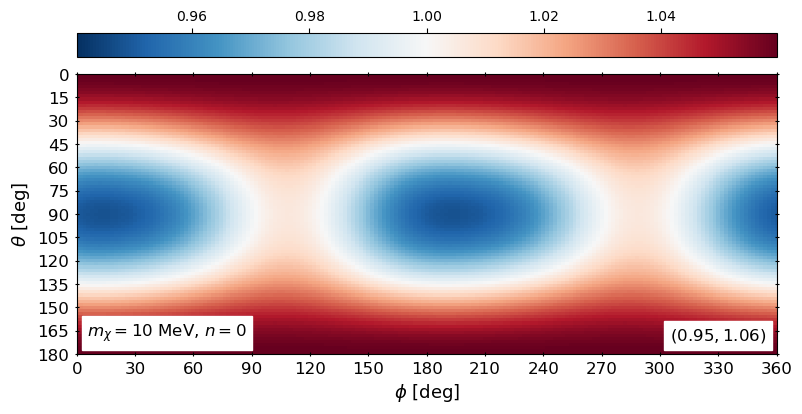

In [30]:
# Make a 2D heatmap showing how the normalized rate varies with the incoming DM direction in crystal-frame angles.

mX = 10
n = 0
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)


xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=False)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=False)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)
            

# ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$, $\beta={}^\circ$'.format(mX, n, beta), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
ax1.text(0.985, 0.035, r'$({:.2f}, {:.2f})$'.format(min_R, max_R), horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)


# ax1.legend(loc='lower center')
# ax1.legend(loc=(0.67, 0.03))


fig.colorbar(mappable=clmapZ, ax=ax1,
             orientation='horizontal', location='top', 
             aspect=30)

# plt.savefig('out/cone/cone_eg_mX{}_n{}.png'.format(mX, n), format="png", dpi=300, bbox_inches='tight')

fig.show()

## Daily Modulation in Fermilab

Using earthspeed to find $v_E(t)$ in the co-rotating lab frame, then converting it to $\theta$ and $\phi$ for a rotated detector. 
This section converts the time-dependent dark matter wind direction at Fermilab into detector/crystal-frame angles, then samples the interpolated rate map along that daily path to compute the modulation curve R(t).

In [31]:
# Compute the current dark-matter-wind direction in local Fermilab altitude/azimuth coordinates.

"""(earthspeed) Example (now): altitude and azimuth for a particular place on Earth"""
date = dts.datetime.now(dts.timezone.utc)
wind = Windfinder([date])
print('Example datetime (UTC):', date)
ra, dec = wind.RAdec[0]
print('Sky position: RA, dec [deg] = ({:.2f}, {:.2f})'.format(ra, dec))

fermilab = EarthLocation(lat='41.838', lon='-88.262', height=0.*u.m)
# snolab = EarthLocation(lat='46.472', lon='-81.188', height=0.*u.m)

altaz = wind.vE_altAz(fermilab)
print('Wilson Hall, Fermilab:')
print('\t vE [km/s]: {:.2f} \t alt [deg]: {:.2f} \t az [deg]: {:.2f}'.format(altaz[0][0], altaz[0][1], altaz[0][2]))

# # Can also use astropy object Windfinder.galactic directly:
# vE_icrs = wind.galactic[0].transform_to(ICRS())
# vE_icrs.dec

Example datetime (UTC): 2026-06-22 05:16:39.024064+00:00
Sky position: RA, dec [deg] = (320.18, 44.26)
Wilson Hall, Fermilab:
	 vE [km/s]: 265.34 	 alt [deg]: 47.71 	 az [deg]: 65.76


In [32]:
# Sample the dark-matter-wind direction over one day at Fermilab and convert it into local 3D vectors.

"""Daily modulation for [May 1, 2025] at [Fermilab]"""

cdt = dts.timezone(dts.timedelta(hours=-5), name='CDT')
midnight = dts.datetime(2025, 5, 1, hour=0, tzinfo=cdt)
midnight.astimezone(dts.timezone.utc)

# 5 samples per hour - samples the day every 12 minutes
dt_per_hour = 5
dt_hours = 1/dt_per_hour
dt = dt_hours * dts.timedelta(hours=1)
obstimes = [midnight + dt * j for j in range(24*dt_per_hour+1)]
location = fermilab

tH = np.zeros(len(obstimes))
vEs = np.zeros(len(obstimes))
alts = np.zeros(len(obstimes))
azs = np.zeros(len(obstimes))

vE_ijk = []
for j,t in enumerate(obstimes):
    vE, alt, az = ethp.vE_AltAz(t, location)
    tH[j] = dt_hours*j 
    vEs[j] = vE
    alts[j] = alt
    azs[j] = az
    th0 = (90 - alt) * np.pi/180 
    ph0 = (-az) * np.pi/180 
    v_x = vE * np.sin(th0) * np.cos(ph0)
    v_y = vE * np.sin(th0) * np.sin(ph0)
    v_z = vE * np.cos(th0)
    vE_ijk += [[0, v_x, v_y, v_z]]
vE_ijk = qnc.array(vE_ijk)

print('altitude min and max [degrees]: {:.3f}, {:.3f}'.format( alts.min(), alts.max()))


altitude min and max [degrees]: -6.321, 89.617


In [33]:
# Check that the local velocity vector magnitude matches the stored dark-matter-wind speed.

print(vE_ijk[15])
print(np.sqrt(vE_ijk[15].norm))
print(vEs[15])

[   0.           70.95961182 -175.00219898  185.10887942]
264.43587767058085
264.43587767058085


In [34]:
# Rotate the daily Fermilab wind vectors into the detector/crystal frame for a chosen gamma alignment.

# initial orientation: z-hat points up, x-hat points north
Uvec = [0, 0, 1] # point UP
Fvec = [1, 0, 0] # point AT CCD
gamma = 0. # azimuthal angle of CCD
Rcrl = getRcrl(Uvec, Fvec, gamma)
print(Rcrl)
vEcell = rotateBy(1/Rcrl, vE_ijk)

# convert to spherical coordinates
thetaE = []
phiE = []
for vE in vEcell:
    v,th,ph = vsdm.cart_to_sph(vE.vector)
    thetaE += [th]
    phiE += [ph]
thetaEd = 180/np.pi * np.array(thetaE)
phiEd = 180/np.pi * np.array(phiE)
#
# phiEd

[1. 0. 0. 0.]


In [35]:
# get R(t) 
data_tot = rn_intp[('tot', 0, 10)]
data_s1 = rn_intp[('s1', 0, 10)]
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS 
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
print(f_tot, f_s1)
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
print(chi2_tot, chi2_s1)


0.03857880113214983 0.031261242573692026
0.001488671033659707 0.0009777094630752593


/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/1536930371.py:133: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


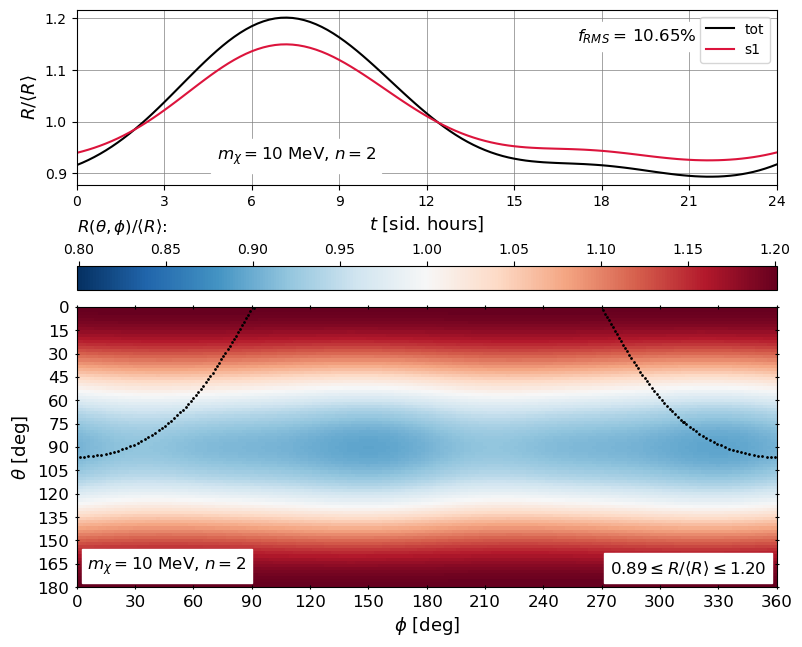

In [37]:
# Plot the daily modulation at Fermilab by tracing the time-dependent DM wind direction across the 2D rate map.

# Choose the DM mass, mediator model, and transition set to plot.
mX = 10
n = 2
sI_2d = 'tot' # index to use for 2d rate plot R(theta, phi)

# get R(t) - Evaluate the interpolated normalized rate along the daily Fermilab wind path.
data_tot = rn_intp[('tot', n, mX)]
data_s1 = rn_intp[('s1', n, mX)]
# compute daily modulation metrics for the total and s1-only rate curves.
RtH = [data_tot([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
RtHs1 = [data_s1([thetaEd[i], phiEd[i]])[0] for i in range(len(tH))]
# get fRMS
f_tot = fRMS(RtH)
f_s1 = fRMS(RtHs1)
# print(f_tot, f_s1)
chi2_tot = chi2norm(RtH)
chi2_s1 = chi2norm(RtHs1)
# print(chi2_tot, chi2_s1)

# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)

# Plot the full directional rate map and overlay the daily wind path.
xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=False)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=False)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

### draw the cone:
ax1.plot(phiEd, thetaEd, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


# Plot the corresponding daily modulation curve as a function of sidereal time
fig.colorbar(mappable=clmapZ, ax=ax1,
             orientation='horizontal', location='top', 
             aspect=30)

ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

sIcolor = {}
sIcolor['tot'] = 'black'
sIcolor['s1'] = 'crimson'
# sIcolor['s1s2'] = 'cornflowerblue'
# sIcolor['s1s5'] = 'slategray'
# sIcolor['s1s8'] = 'mediumpurple'
nstyle = {'A': 'solid', 'B': 'dashed'}
sIs = ['s1', 'tot']

ax2.plot(tH, RtH, color=sIcolor['tot'], label='tot')
ax2.plot(tH, RtHs1, color=sIcolor['s1'], label='s1')

# mX, n label:
ax2.text(0.2, 0.1, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)
# fRMS score:
ax2.text(0.8, 0.9, r'$f_{RMS} = \,$' + r'${:.2f}\%$'.format(f_tot*100), 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()

# plt.savefig('out/modRate_mX{}_n{}_initial.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

# Orthogonal Bases for non-cubic cubes

There are multiple ways to construct orthogonal systems out of the not-quite-orthogonal normal vectors for cube faces A, B and C. As a measure of the angular uncertainty, we generate an ensemble of possible cubifications of the cube. Each orthogonal system is co-axial with one of the three experimentally measured normal vectors.

In [38]:
cubes = [i for i in range(1, 7)]
# orthogonal bases (0..5), six for each cube
bases = {}
orth_ixs = []
for cube in cubes:
    orth_ix = (cube, 0)
    orth_ixs += [orth_ix]
    not_orth = np.array([uvecs[str(cube)+lbl] for lbl in ['a', 'b', 'c']])
    bases[orth_ix] = not_orth
    # store both positive and negative face directions so all physical cube orientations can be tested.
    bases[(cube, 0, 'a')] = not_orth[0]
    bases[(cube, 0, 'b')] = not_orth[1]
    bases[(cube, 0, 'c')] = not_orth[2]
    bases[(cube, 0, '-a')] = not_orth[0] * (-1)
    bases[(cube, 0, '-b')] = not_orth[1] * (-1)
    bases[(cube, 0, '-c')] = not_orth[2] * (-1)
    for p in range(len(pabcs)):
        pabc = pabcs[p] 
        orth_ix = (cube, p+1)
        orth_ixs += [orth_ix]
        uo = cubify(uvecs, cube, pabc)
        bases[orth_ix] = uo
        bases[(cube, p+1, 'a')] = uo[0]
        bases[(cube, p+1, 'b')] = uo[1]
        bases[(cube, p+1, 'c')] = uo[2]
        bases[(cube, p+1, '-a')] = uo[0] * (-1)
        bases[(cube, p+1, '-b')] = uo[1] * (-1)
        bases[(cube, p+1, '-c')] = uo[2] * (-1)
# with permutations of ('a', 'b', 'c'), it is convenient to label the basis vectors with letters

In [39]:
# Inspect example stored basis vectors to verify the orthogonalized cube bases.

print(bases[(2, 0)])
print(bases[(2, 4, 'c')])

[[ 1.          0.          0.        ]
 [ 0.00299598  0.9910483  -0.13347022]
 [ 0.13237982  0.41725108  0.89909795]]
[-0.          0.42095589  0.90708111]


### Distance between cube orientations in $SO(3) \simeq S^3$

To make sure that each of the six versions of the cube are nearby, check the angular variation in each axis. 

In [40]:
# Check how much each cube's possible orthogonalized bases vary from a reference basis.

p = 0 # pick a choice for (up, face, other) 
pabc = pabcs[p] 
gamma = 0. * np.pi/180
for cube in range(1, 7):
    uA = bases[(cube, 0, 'a')]
    uB = bases[(cube, 0, 'b')]
    uC = bases[(cube, 0, 'c')]
    up0 = bases[(cube, 0, pabc[0])]
    fc0 = bases[(cube, 0, pabc[1])]
    Q0 = getRcrl(up0, fc0, gamma)
    diffR = []
    for pp in range(1, 7):
        uAp = bases[(cube, pp, 'a')]
        uBp = bases[(cube, pp, 'b')]
        uCp = bases[(cube, pp, 'c')]
        dots = (uA @ uAp, uB @ uBp, uC @ uCp)
        upp = bases[(cube, pp, pabc[0])]
        fcp = bases[(cube, pp, pabc[1])]
        Qp = getRcrl(upp, fcp, gamma)
        Qdiff = Qp / Q0
        QdR = Qdiff.scalar
        diffR += [QdR]
        print(cube, pp, '({:.3f}, {:.3f}, {:.3f})'.format(dots[0], dots[1], dots[2]), '{:.5f}'.format(QdR))
    diffR = np.array(np.abs(diffR))
    avgDR = np.mean(diffR)
    stdDR = np.std(diffR)
    brad = 2**1.5 * np.sqrt(1-avgDR)
    # brad = 2 * np.arccos(avgDR)
    print('\t 1 - cos(b/2) = {:.4g} +- {:.3g}'.format(1-avgDR, stdDR))
    print('\t            b = {:.1f} deg'.format(brad*180/np.pi))
    

1 1 (1.000, 0.732, 0.843) 1.00000
1 2 (0.642, 1.000, 0.960) 0.90153
1 3 (0.850, 0.726, 1.000) 0.95966
1 4 (1.000, 0.726, 0.850) 0.99790
1 5 (0.642, 0.960, 1.000) 0.90531
1 6 (0.732, 1.000, 0.843) 0.93050
	 1 - cos(b/2) = 0.05085 +- 0.04
	            b = 36.5 deg
2 1 (1.000, 1.000, 0.947) 1.00000
2 2 (0.990, 1.000, 0.956) 0.99762
2 3 (0.991, 0.955, 1.000) 0.98655
2 4 (1.000, 0.955, 0.991) 0.98872
2 5 (0.990, 0.956, 1.000) 0.98656
2 6 (1.000, 1.000, 0.947) 1.00000
	 1 - cos(b/2) = 0.006759 +- 0.00606
	            b = 13.3 deg
3 1 (1.000, 0.757, 0.943) 1.00000
3 2 (0.756, 1.000, 0.944) 0.93689
3 3 (0.983, 0.725, 1.000) 0.98544
3 4 (1.000, 0.725, 0.983) 0.98956
3 5 (0.756, 0.944, 1.000) 0.92216
3 6 (0.757, 1.000, 0.943) 0.93717
	 1 - cos(b/2) = 0.03813 +- 0.0305
	            b = 31.6 deg
4 1 (1.000, 0.972, 0.713) 1.00000
4 2 (0.695, 1.000, 0.998) 0.91939
4 3 (0.746, 0.930, 1.000) 0.92401
4 4 (1.000, 0.930, 0.746) 0.98908
4 5 (0.695, 0.998, 1.000) 0.91779
4 6 (0.972, 1.000, 0.713) 0.99308
	

In [41]:
"""Enumerate all 24 cube orientations by (UP, CCD) faces: """
UFs = [('a', 'b'), ('a', 'c'), ('a', '-b'), ('a', '-c')]
UFs += [('b', 'a'), ('b', 'c'), ('b', '-a'), ('b', '-c')]
UFs += [('c', 'a'), ('c', 'b'), ('c', '-a'), ('c', '-b')]
UFs += [('-a', 'b'), ('-a', 'c'), ('-a', '-b'), ('-a', '-c')]
UFs += [('-b', 'a'), ('-b', 'c'), ('-b', '-a'), ('-b', '-c')]
UFs += [('-c', 'a'), ('-c', 'b'), ('-c', '-a'), ('-c', '-b')]


In [42]:
# convert the daily wind path into crystal-frame theta/phi angles for a chosen cube orientation and gamma.

def thetaphi_cell(vEq_crl, up_vec, face_vec, gamma):
    Rcrl = getRcrl(up_vec, face_vec, gamma)
    vEcell = rotateBy(1/Rcrl, vEq_crl)
    
    # convert to spherical coordinates
    thetaE = []
    phiE = []
    for vE in vEcell:
        v,th,ph = vsdm.cart_to_sph(vE.vector)
        thetaE += [th]
        phiE += [ph]
    return np.array(thetaE), np.array(phiE) #in radians
    


In [43]:
# Test all 24 cube orientations and gamma=0 to see which ones produce the largest daily modulation in the total rate, and second-largest modulation in the s1-only rate.

gamma = 0 
model = ('tot', 2, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_uf = {}
phid_uf = {}
Rt_uf = {}
fRMS_uf = {}
score_uf = {}
best_uf = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
        thD = 180/np.pi * thE
        phD = 180/np.pi * phE
        thph_ix = (cube, pp, p)
        thetad_uf[thph_ix] = thD
        phid_uf[thph_ix] = phD
        # sample the normalized rate along the daily wind path for this cube orientation
        RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
        Rt_uf[thph_ix] = np.array(RtH)
        # compute modulation metrics for this cube orientation
        fRMS_uf[thph_ix] = fRMS(RtH)
        score_uf[thph_ix] = chi2norm(RtH)
    scores = [score_uf[(cube, pp, p)] for p in range(len(UFs))]
    maxscore = np.max(scores)
    p_best = scores.index(maxscore)
    # record the best and second-best UP/face combinations for this cube orientation
    otherscores = scores[:p_best] + scores[p_best+1:]
    nextmax = np.max(otherscores)
    p_second = otherscores.index(nextmax)
    p_second += int(p_second >= p_best)
    best_uf[orth_ix] = [p_best, p_second]
    print('{}:'.format(orth_ix), UFs[p_best], UFs[p_second])
        

(1, 0): ('b', '-c') ('a', 'c')
(1, 1): ('a', 'c') ('-a', '-c')
(1, 2): ('b', '-c') ('-b', 'c')
(1, 3): ('b', '-c') ('-c', 'b')
(1, 4): ('c', '-a') ('-c', 'a')
(1, 5): ('-b', 'a') ('b', '-a')
(1, 6): ('-c', 'b') ('c', '-b')
(2, 0): ('-a', 'c') ('c', '-a')
(2, 1): ('-c', 'a') ('-c', '-a')
(2, 2): ('a', 'c') ('-a', '-c')
(2, 3): ('c', '-a') ('-c', 'a')
(2, 4): ('-a', 'c') ('a', '-c')
(2, 5): ('c', '-a') ('-c', 'a')
(2, 6): ('c', '-a') ('-c', 'a')
(3, 0): ('a', '-c') ('-a', 'c')
(3, 1): ('-c', 'a') ('c', 'a')
(3, 2): ('c', 'b') ('-b', 'c')
(3, 3): ('c', 'a') ('-c', '-a')
(3, 4): ('a', '-c') ('-a', 'c')
(3, 5): ('-c', 'a') ('c', '-a')
(3, 6): ('-b', 'c') ('b', '-c')
(4, 0): ('a', 'c') ('-a', '-c')
(4, 1): ('c', 'a') ('c', '-a')
(4, 2): ('-b', 'a') ('b', '-a')
(4, 3): ('-a', 'b') ('a', '-b')
(4, 4): ('a', 'c') ('-a', '-c')
(4, 5): ('-b', 'a') ('b', '-a')
(4, 6): ('a', 'c') ('-a', '-c')
(5, 0): ('a', '-b') ('-a', 'b')
(5, 1): ('-b', 'a') ('-b', '-a')
(5, 2): ('a', '-b') ('-a', 'b')
(5, 3): ('

Note that the more cubelike cubes (2, 5, 6) are more consistent in their predictions for the optimal orientations.

## Daily Modulation Plots

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3516583998.py:134: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


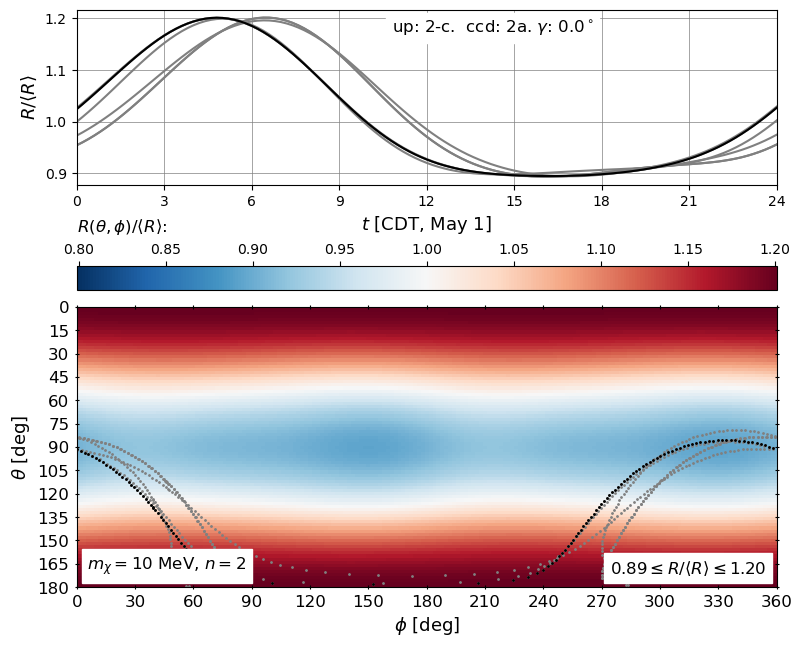

In [45]:
# Select one cube and its best UP/CCD orientation for plotting 
cube = 2
pp_ix = 1 # black curve in plots
p = best_uf[(cube, pp_ix)][0] # UP/FACE combination (cube_ix, pp_ix)
# p = best_uf[(cube, pp_ix)][1] # UP/FACE combination (cube_ix, pp_ix)

# Get the face labels for this cube and UP/FACE choice, to use in plot titles
upface = (str(cube)+UFs[p][0], str(cube)+UFs[p][1])
# fRMS_this 

# Set symmetric colorbar limits for the 2D rate plot, based on the minimum and maximum normalized rates across the theta-phi grid for this model
sI_2d, n, mX = model # index to use for 2d rate plot R(theta, phi)
# min_z = np.min(rate_norm[(mX, n)])
# max_z = np.max(rate_norm[(mX, n)])
min_R = np.min(rate_norm[(sI_2d, n, mX)])
max_R = np.max(rate_norm[(sI_2d, n, mX)])
maxdiff = np.max([max_R-1, 1-min_R])
min_z = 1 - maxdiff
max_z = 1 + maxdiff

# colorZ = 'PuOr_r'
# colorZ = 'PRGn_r'
# colorZ = 'RdGy_r'
colorZ = 'RdBu_r'
cnormZ = plt.Normalize(vmin=min_z, vmax=max_z)
clmapZ = plt.cm.ScalarMappable(norm=cnormZ, cmap=colorZ)

# Plot the normalized 2D rate map R(theta, phi)/<R> and overlay the daily wind path for the selected cube orientation.
xlim = [0, 360]
ylim = [180, 0]
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax1 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_xlabel(r'$\phi$ [deg]', fontsize=13, usetex=False)
ax1.set_ylabel(r'$\theta$ [deg]', fontsize=13, usetex=False)
ax1.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax1.set_xticks([ph for ph in range(0, 361, 30)])
ax1.set_yticks([th for th in range(0, 181, 15)])

### 2d rate R(theta,phi):
ax1.pcolormesh(phis, thetas, rate_norm[(sI_2d, n, mX)], shading='nearest', 
               cmap=colorZ, vmin=min_z, vmax=max_z)

# Overlay daily theta/phi trajectories for the cube's orthogonalized bases (gray) and reference basis (black)
### draw the cones:
for pp in range(1, 7):
# for pp in [1, 2, 6]:
    # orth_ix = (cube, pp)
    thetaEd = thetad_uf[(cube, pp, p)]
    phiEd = phid_uf[(cube, pp, p)]
    ax1.plot(phiEd, thetaEd, 'o', color='gray', markersize=1)
thetaEd = thetad_uf[(cube, 0, p)]
phiEd = phid_uf[(cube, 0, p)]
ax1.plot(phiEd, thetaEd, 'o', color='black', markersize=1)

            
ax1.text(0.015, 0.035, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
ax1.text(0.985, 0.035, r'${:.2f} \leq R/\langle R \rangle \leq {:.2f}$'.format(min_R, max_R), 
         horizontalalignment='right',
         verticalalignment='bottom', fontsize=12, 
         color='black', backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
         horizontalalignment='left',
         verticalalignment='bottom', fontsize=12, 
         color='black', 
         # backgroundcolor='white',
         transform=ax1.transAxes, usetex=False)
# ax1.text(0.0, 1.25, r'$R(\theta,\phi) / \langle R \rangle$:', 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          # backgroundcolor='white',
#          transform=ax1.transAxes, usetex=True)


fig.colorbar(mappable=clmapZ, ax=ax1,
             orientation='horizontal', location='top', 
             aspect=30)

# Create the top panel showing the daily modulation R(t)
ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

# Plot R(t) for each orthogonalized basis and highlight the reference basis in black
### draw the cones:
for pp in range(1, 7):
# for pp in [1, 2, 6]:
    # orth_ix = (cube, pp)
    RtH = Rt_uf[(cube, pp, p)]
    ax2.plot(tH, RtH, color='gray')
RtH = Rt_uf[(cube, 0, p)]
ax2.plot(tH, RtH, color='black')

# Label the chosen cube orientation and detector gamma
# # mX, n label:
# ax2.text(0.2, 0.1, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          backgroundcolor='white',
#          transform=ax2.transAxes, usetex=False)
# fRMS score:
ax2.text(0.45, 0.95, r'up: {}.  ccd: {}. $\gamma$: ${}^\circ$'.format(upface[0], upface[1], gamma*180/np.pi), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
# ax2.legend()
gammaD = int(gamma*180/np.pi)

# Save the combined rate-map and daily-modulation plot
plt.savefig('out/cube_{}_{}_g{}.png'.format(upface[0], upface[1], int(gamma*180/np.pi)), 
            format="png", dpi=600, bbox_inches='tight')

fig.show()

In [46]:
# Optional: save the daily modulation curve R(t) and time array to CSV.

# """SAVE THIS R(t) TO CSV FILE"""
# np.savetxt('out/tH.csv', tH)
# np.savetxt('out/RtH_{}_{}_g{}.csv'.format(upface[0], upface[1], int(gamma*180/np.pi)), RtH)

# Scan Over CCD Placement

### RMS amplitude and significance score 

In the gaussian limit of many ($\gtrsim 50$) events per day, the expected statistical significance of a modulating signal scales as $N_\sigma \approx \sqrt{ \chi^2}$, with 
$$\chi^2 \simeq (R_0 T) \times f_{\rm RMS}^2,$$ 
$$f_{\rm RMS} = \frac{1}{R_0} \sqrt{\int_0^T \frac{dt}{T} \left( R(t) - R_0 \right)^2}.$$
Here $T$ is the observation time, and $R_0$ is the average number of events (i.e. $R_0 T$ is the total number of events). The rate $R(t)$ is either the measured distribution of events as a function of time, or it is the predicted rate of events: including a DM signal $R_{\rm DM}$ and a constant background $R_{\rm background}$, for example,
$$ R(t) = R_{\rm DM}(t) + R_{\rm background}.$$ 

In [47]:
# Scan gamma and compute R(t), fRMS, and score for every cube orientation

gammaDs = [g for g in range(0, 361, 3)]
model = ('tot', 2, 10) 
rate_thphd = rn_intp[model]

# thetad_uf = {}
# phid_uf = {}
# Rt_uf = {}
# fRMS_uf = {}
# score_uf = {}
# best_uf = {}
t0 = time.time()
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # six different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thph_ix = (cube, pp, p)
        fRMS_uf[thph_ix] = []
        score_uf[thph_ix] = []
        for gD in gammaDs:
            gamma = gD * np.pi/180
            thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
            thD = 180/np.pi * thE
            phD = 180/np.pi * phE
            thphg_ix = (cube, pp, p, gD)
            thetad_uf[thphg_ix] = thD
            phid_uf[thphg_ix] = phD
            RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
            Rt_uf[thphg_ix] = np.array(RtH)
            fRMS_uf[thph_ix] += [fRMS(RtH)]
            score_uf[thph_ix] += [chi2norm(RtH)]
    # scores = [score_uf[(cube, pp, p)] for p in range(len(pabcs))]
    # maxscore = np.max(scores)
    # p_best = scores.index(maxscore)
    # otherscores = scores[:p_best] + scores[p_best+1:]
    # nextmax = np.max(otherscores)
    # p_second = otherscores.index(nextmax)
    # p_second += int(p_second >= p_best)
    # best_uf[orth_ix] = [p_best, p_second]
    # print('{}:'.format(orth_ix), pabcs[p_best], pabcs[p_second]

# Print evalutation/execution time to go through the loop
tEval = time.time() - t0
print(tEval)

365.26294898986816


In [48]:
# Store the best fRMS and score across all UP/CCD orientations for each gamma.

fRMS_max = {}
score_max = {}
uf_bestF = {}
uf_bestS = {}
# uf_ranked = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    fRMS_max[orth_ix] = []
    score_max[orth_ix] = []
    uf_bestF[orth_ix] = []
    uf_bestS[orth_ix] = []
    for gix in range(len(gammaDs)):
        ffs = [fRMS_uf[(cube, pp, p)][gix] for p in range(len(UFs))]
        fmax = np.max(ffs)
        sfs = [score_uf[(cube, pp, p)][gix] for p in range(len(UFs))]
        smax = np.max(sfs)
        fRMS_max[orth_ix] += [fmax]
        score_max[orth_ix] += [smax]
        for p in range(len(UFs)):
            f_p = []
            s_p = []
            if fRMS_uf[(cube, pp, p)][gix] == fmax:
                f_p += [p]
            if score_uf[(cube, pp, p)][gix] == smax:
                s_p += [p]
            uf_bestF[orth_ix] += [f_p]
            uf_bestS[orth_ix] += [s_p]

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/1189502192.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


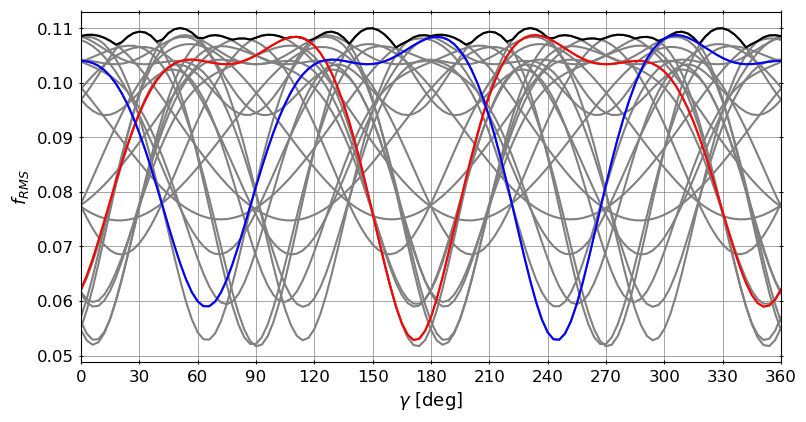

In [49]:
# Plot fRMS versus gamma for all orientations, highlighting selected examples

cube = 2
pp = 0 # which cube version of (UP, FACE) to show

pc1 = 0
pc2 = 1

fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
# ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$\gamma$ [deg]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$f_{RMS}$', fontsize=13, usetex=False)
ax2.set_xlim([0,360])
ax2.set_xticks([ph for ph in range(0, 361, 30)])
# ax2.set_ylim([min_R, max_R])
ax2.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

### draw the cones:
for p,uf in enumerate(UFs):
    frms = np.array(fRMS_uf[cube, pp, p])
    ax2.plot(gammaDs, frms, color='gray', label=pabc)
# RtH = Rt_uf[(cube, 0, p)]
ax2.plot(gammaDs, fRMS_max[cube, pp], color='black')

# highlights: 
frms = np.array(fRMS_uf[cube, pp, pc1])
ax2.plot(gammaDs, frms, color='red', label=UFs[pc1])
frms = np.array(fRMS_uf[cube, pp, pc2])
ax2.plot(gammaDs, frms, color='blue', label=UFs[pc2])

# ax2.legend()
# plt.savefig('out/fRMS_cube{}.pdf'.format(cube), 
#             format="pdf", bbox_inches='tight')

fig.show()

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/181321430.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


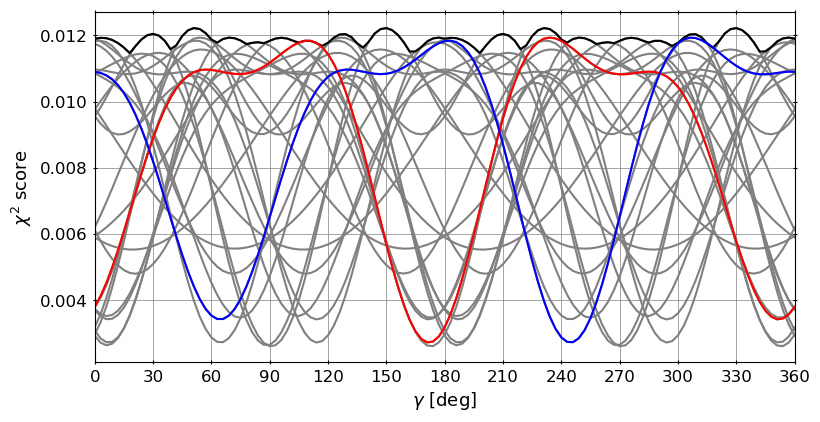

In [50]:
# Similar to previous cell, but plotting chi2-style score versus gamma for all orientations.

cube = 2
pp = 0

pc1 = 0
pc2 = 1

fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
# ax2 = fig.add_axes([0,1.15,1,0.5], xscale='linear', yscale='linear')
ax2.set_xlabel(r'$\gamma$ [deg]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$\chi^2$ score', fontsize=13, usetex=False)
ax2.set_xlim([0,360])
ax2.set_xticks([ph for ph in range(0, 361, 30)])
# ax2.set_ylim([min_R, max_R])
ax2.tick_params(axis='both', labelsize=12, direction='inout',
                right=True, top=True, labelleft=True, labelright=False,
                labelbottom=True, labeltop=False)
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

### draw the cones:
for p,uf in enumerate(UFs):
    sc = np.array(score_uf[cube, pp, p])
    ax2.plot(gammaDs, sc, color='gray', label=pabc)
# RtH = Rt_uf[(cube, 0, p)]
ax2.plot(gammaDs, score_max[cube, pp], color='black')

# highlights: 
sc = np.array(score_uf[cube, pp, pc1])
ax2.plot(gammaDs, sc, color='red', label=UFs[pc1])
sc = np.array(score_uf[cube, pp, pc2])
ax2.plot(gammaDs, sc, color='blue', label=UFs[pc2])

# ax2.legend()
# plt.savefig('out/chi2_cube{}.pdf'.format(cube), 
#             format="pdf", bbox_inches='tight')

fig.show()

In [51]:
# Print selected UP/CCD orientation labels for reference

print(UFs[pc1], UFs[pc2])

('a', 'b') ('a', 'c')


In [52]:
# Quick check of the maximum fRMS value for cube 5

np.max(fRMS_max[5, pp])

0.10877979167560957

# Specific Choices for Fermilab

Optimizing for the $m_\chi = 10$ MeV DM models, with heavy and light mediators. 
* cubes 5 and 6: optimized for $n = 0$ model, to have non-overlapping $R(t)$ phases
* cube 2: optimize for $n = 2$

Repeat for $\gamma = 0^\circ, 15^\circ, 30^\circ, 45^\circ, 60^\circ, 75^\circ$. 

### $\gamma = 0^\circ$ for $n = 0$ mediator model

In [53]:
# Compute R(t), fRMS, and score for each orientation, then store the top four UP/CCD choices

gamma = 0 
n = 0
model = ('tot', n, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_uf = {}
phid_uf = {}
Rt_uf = {}
fRMS_uf = {}
score_uf = {}
best_uf = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
        thD = 180/np.pi * thE
        phD = 180/np.pi * phE
        thph_ix = (cube, pp, p)
        thetad_uf[thph_ix] = thD
        phid_uf[thph_ix] = phD
        RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
        Rt_uf[thph_ix] = np.array(RtH)
        fRMS_uf[thph_ix] = fRMS(RtH)
        score_uf[thph_ix] = chi2norm(RtH)
    scores = [score_uf[(cube, pp, p)] for p in range(len(UFs))]
    maxscore = np.max(scores)
    p_best = scores.index(maxscore)
    # from the others, select the second best:
    otherscores = scores[:p_best] + scores[p_best+1:]
    nextmax = np.max(otherscores)
    p_second = otherscores.index(nextmax)
    # ... and the third best
    thirdscores = otherscores[:p_second] + otherscores[p_second+1:]
    thirdmax = np.max(thirdscores)
    p_third = thirdscores.index(thirdmax)
    # ... etc
    fourscores = thirdscores[:p_third] + thirdscores[p_third+1:]
    fourmax = np.max(fourscores)
    p_four = fourscores.index(fourmax)
    # convert index from 'others' and 'third' to index of original 'scores'
    p_second += int(p_second >= p_best)
    p_third += int(p_third >= p_best)
    p_third += int(p_third >= p_second)
    p_four += int(p_four >= p_best)
    p_four += int(p_four >= p_second)
    p_four += int(p_four >= p_third)
    best_uf[orth_ix] = [p_best, p_second, p_third, p_four]
    print('{}:'.format(orth_ix), str(p_best)+':'+str(UFs[p_best]), 
                       str(p_second)+':'+str(UFs[p_second]), 
                       str(p_third)+':'+str(UFs[p_third]), 
                       str(p_four)+':'+str(UFs[p_four]), 
         )
        

(1, 0): 15:('-a', '-c') 1:('a', 'c') 17:('-b', 'c') 7:('b', '-c')
(1, 1): 15:('-a', '-c') 1:('a', 'c') 22:('-c', '-a') 8:('c', 'a')
(1, 2): 17:('-b', 'c') 7:('b', '-c') 16:('-b', 'a') 6:('b', '-a')
(1, 3): 18:('-b', '-a') 4:('b', 'a') 14:('-a', '-b') 0:('a', 'b')
(1, 4): 15:('-a', '-c') 1:('a', 'c') 22:('-c', '-a') 8:('c', 'a')
(1, 5): 16:('-b', 'a') 6:('b', '-a') 2:('a', '-b') 12:('-a', 'b')
(1, 6): 1:('a', 'c') 15:('-a', '-c') 10:('c', '-a') 20:('-c', 'a')
(2, 0): 15:('-a', '-c') 1:('a', 'c') 13:('-a', 'c') 3:('a', '-c')
(2, 1): 15:('-a', '-c') 1:('a', 'c') 8:('c', 'a') 10:('c', '-a')
(2, 2): 15:('-a', '-c') 1:('a', 'c') 20:('-c', 'a') 10:('c', '-a')
(2, 3): 15:('-a', '-c') 1:('a', 'c') 22:('-c', '-a') 20:('-c', 'a')
(2, 4): 15:('-a', '-c') 1:('a', 'c') 8:('c', 'a') 10:('c', '-a')
(2, 5): 15:('-a', '-c') 1:('a', 'c') 20:('-c', 'a') 10:('c', '-a')
(2, 6): 22:('-c', '-a') 15:('-a', '-c') 1:('a', 'c') 8:('c', 'a')
(3, 0): 7:('b', '-c') 17:('-b', 'c') 13:('-a', 'c') 3:('a', '-c')
(3, 1):

The following code visualizes the 24-hour normalized event rates for three detector modules (Cube 2, 5, 6) and maps out how their top 4 geometric configurations (p1-p4) modulate as the Earth rotates. 

It's important that these configurations do not peak at the same time; this phase seperation breaks geometric degeneracy and allows us to reconstruct the exact directional vector of the incoming signal in space. Furthermore, local lab backgrounds (like temperature or power fluctuations) usually peak at the same time every day regardless of detector orientation. Hence, distinct and predictable time shits allow us to rule out environmental noise and maximize experiment sensitivity.

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/4224487331.py:145: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


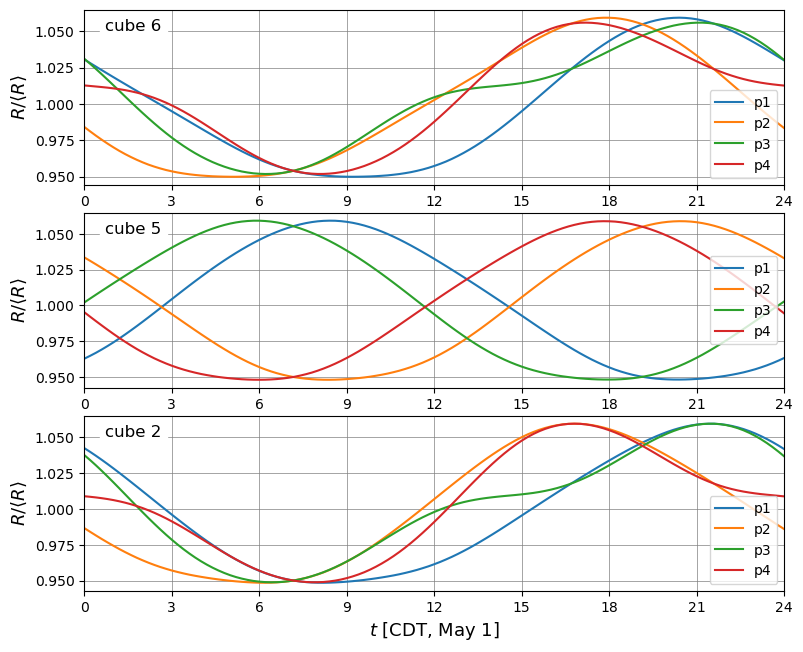

In [54]:
fig = plt.figure(figsize=[2.0*unisize,unisize])
pp_ix = 0 # which cube version to use to define UP and FACE

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)
# p = best_uf[(cube, pp_ix)][1] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])
# fRMS_this 

pA = p1 
pB = p4

ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

### draw the cones:
# for pp in range(1, 7):
#     RtHa = Rt_uf[(cube, pp, pA)]
#     RtHb = Rt_uf[(cube, pp, pB)]
#     ax2.plot(tH, RtHa, color='gray')
#     ax2.plot(tH, RtHb, color='gray', linestyle='dashed')
RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
# ax2.plot(tH, RtH1, color='black', label=upface1)
# ax2.plot(tH, RtH2, color='black', linestyle='dashed', label=upface2)
ax2.plot(tH, RtH1, label='p1')
ax2.plot(tH, RtH2, label='p2')
ax2.plot(tH, RtH3, label='p3')
ax2.plot(tH, RtH4, label='p4')

# # mX, n label:
# ax2.text(0.2, 0.1, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          backgroundcolor='white',
#          transform=ax2.transAxes, usetex=True)
# fRMS score:
gammaD = int(gamma*180/np.pi)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()



cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax5.plot(tH, RtH1, label='p1')
ax5.plot(tH, RtH2, label='p2')
ax5.plot(tH, RtH3, label='p3')
ax5.plot(tH, RtH4, label='p4')


ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax6.plot(tH, RtH1, label='p1')
ax6.plot(tH, RtH2, label='p2')
ax6.plot(tH, RtH3, label='p3')
ax6.plot(tH, RtH4, label='p4')


ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend()


plt.savefig('out/options_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

Making a selection for $\gamma = 0^\circ$:
* cube 6: p3 = 0:('a', 'b'), for late-evening maximum and interesting early-afternoon shoulder feature
* cube 5: p1 = 4:('b', 'a'), for maximum out-of-phase wrt cube 6
* cube 2: p2 = 1:('a', 'c'), for separation from cube 6

In [55]:
# Small setup for plotting the daily modulation curves R(t) for the top four UP/CCD orientations for cubes 2, 5, and 6

cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = p1 # p=4  
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = p3 # p=0
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])



/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3808030708.py:124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


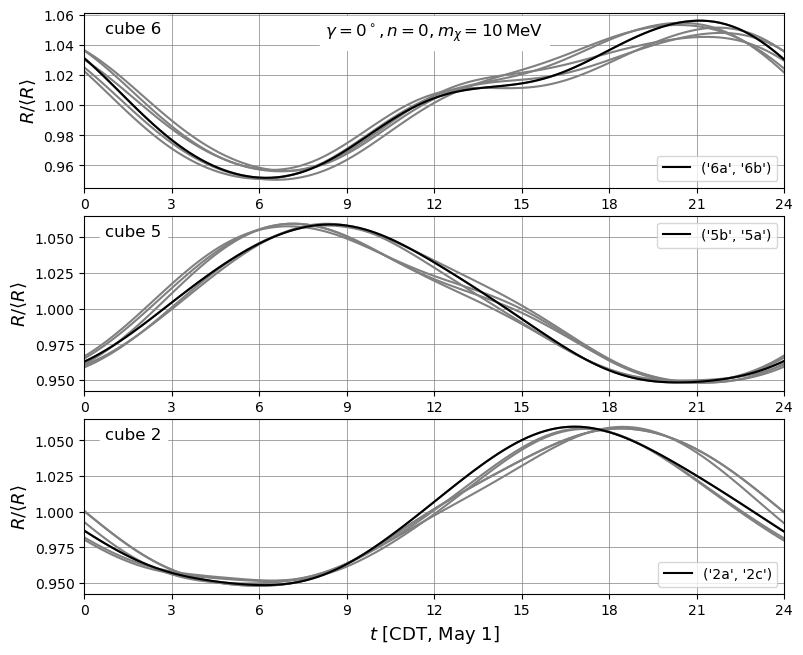

In [56]:
# Plot the selected cube orientations and compare geometry-uncertainty variations in R(t)

fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)
pp_ix = 0 # which cube version to use to define UP and FACE

makeCSV = False

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = p2 # p=1
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])

# For plotting: Gray curves show the variation across orthogonalized versions of the cube geometry
# Black curve shows the reference cube-basis version for the selected orientation
ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax2.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax2.plot(tH, RtHa, color='black', label=upfaceA)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

ax2.legend(loc='lower right')

# Rt_2 = RtHa
if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)

cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = p1 # p=4  
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax5.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax5.plot(tH, RtHa, color='black', label=upfaceA)

ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()

# Rt_5 = RtHa
if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = p3 # p=0
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax6.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax6.plot(tH, RtHa, color='black', label=upfaceA)


ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend(loc='lower right')

ax6.text(0.5, 0.95, r'$\gamma = {}^\circ, n = {}, m_\chi = {}$'.format(gammaD, n, mX) + r'$\,{\rm MeV}$', 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)

# Rt_6 = RtHa
if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)

               
plt.savefig('out/choices_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

In [57]:
# Optional: save the Fermilab time grid to CSV

# np.savetxt('out/tH_fermilab.csv', tH)

### $\gamma = 0^\circ$ for $n = 2$ mediator model

In [58]:
# Compute R(t), fRMS, and score for each orientation, then store the top four UP/CCD choices

gamma = 0 
n = 2
model = ('tot', n, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_uf = {}
phid_uf = {}
Rt_uf = {}
fRMS_uf = {}
score_uf = {}
best_uf = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
        thD = 180/np.pi * thE
        phD = 180/np.pi * phE
        thph_ix = (cube, pp, p)
        thetad_uf[thph_ix] = thD
        phid_uf[thph_ix] = phD
        RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
        Rt_uf[thph_ix] = np.array(RtH)
        fRMS_uf[thph_ix] = fRMS(RtH)
        score_uf[thph_ix] = chi2norm(RtH)
    scores = [score_uf[(cube, pp, p)] for p in range(len(UFs))]
    maxscore = np.max(scores)
    p_best = scores.index(maxscore)
    # from the others, select the second best:
    otherscores = scores[:p_best] + scores[p_best+1:]
    nextmax = np.max(otherscores)
    p_second = otherscores.index(nextmax)
    # ... and the third best
    thirdscores = otherscores[:p_second] + otherscores[p_second+1:]
    thirdmax = np.max(thirdscores)
    p_third = thirdscores.index(thirdmax)
    # ... etc
    fourscores = thirdscores[:p_third] + thirdscores[p_third+1:]
    fourmax = np.max(fourscores)
    p_four = fourscores.index(fourmax)
    # convert index from 'others' and 'third' to index of original 'scores'
    p_second += int(p_second >= p_best)
    p_third += int(p_third >= p_best)
    p_third += int(p_third >= p_second)
    p_four += int(p_four >= p_best)
    p_four += int(p_four >= p_second)
    p_four += int(p_four >= p_third)
    best_uf[orth_ix] = [p_best, p_second, p_third, p_four]
    print('{}:'.format(orth_ix), str(p_best)+':'+str(UFs[p_best]), 
                       str(p_second)+':'+str(UFs[p_second]), 
                       str(p_third)+':'+str(UFs[p_third]), 
                       str(p_four)+':'+str(UFs[p_four]), 
         )
        

(1, 0): 7:('b', '-c') 1:('a', 'c') 15:('-a', '-c') 17:('-b', 'c')
(1, 1): 1:('a', 'c') 15:('-a', '-c') 10:('c', '-a') 20:('-c', 'a')
(1, 2): 7:('b', '-c') 17:('-b', 'c') 5:('b', 'c') 19:('-b', '-c')
(1, 3): 7:('b', '-c') 21:('-c', 'b') 11:('c', '-b') 17:('-b', 'c')
(1, 4): 10:('c', '-a') 20:('-c', 'a') 1:('a', 'c') 15:('-a', '-c')
(1, 5): 16:('-b', 'a') 6:('b', '-a') 2:('a', '-b') 12:('-a', 'b')
(1, 6): 21:('-c', 'b') 11:('c', '-b') 9:('c', 'b') 22:('-c', '-a')
(2, 0): 13:('-a', 'c') 10:('c', '-a') 3:('a', '-c') 20:('-c', 'a')
(2, 1): 20:('-c', 'a') 22:('-c', '-a') 8:('c', 'a') 10:('c', '-a')
(2, 2): 1:('a', 'c') 15:('-a', '-c') 10:('c', '-a') 20:('-c', 'a')
(2, 3): 10:('c', '-a') 20:('-c', 'a') 13:('-a', 'c') 3:('a', '-c')
(2, 4): 13:('-a', 'c') 3:('a', '-c') 20:('-c', 'a') 22:('-c', '-a')
(2, 5): 10:('c', '-a') 20:('-c', 'a') 13:('-a', 'c') 3:('a', '-c')
(2, 6): 10:('c', '-a') 20:('-c', 'a') 22:('-c', '-a') 8:('c', 'a')
(3, 0): 3:('a', '-c') 13:('-a', 'c') 1:('a', 'c') 15:('-a', '-c'

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/2029954873.py:147: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


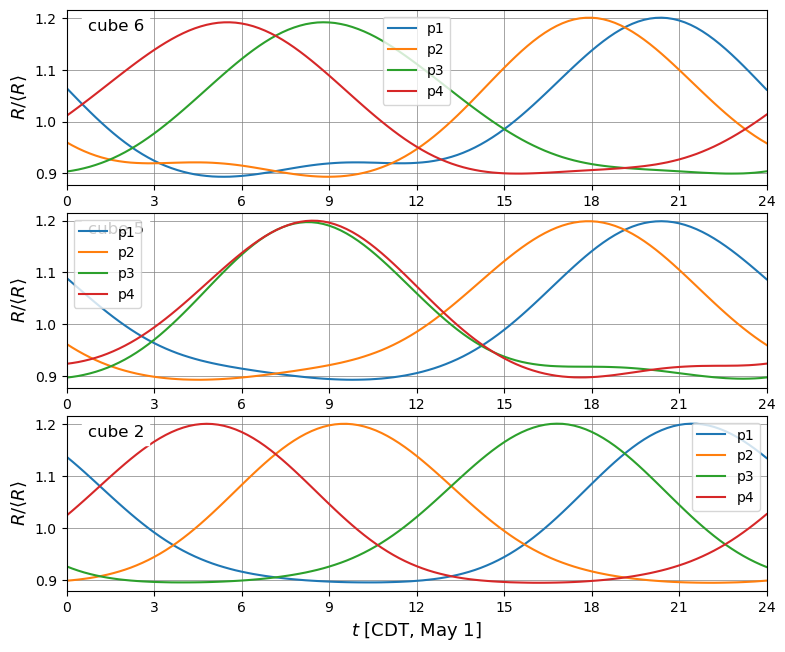

In [59]:
# Plot the top four candidate daily modulation curves for cubes 2, 5, and 6

fig = plt.figure(figsize=[2.0*unisize,unisize])
pp_ix = 0 # which cube version to use to define UP and FACE

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)
# p = best_uf[(cube, pp_ix)][1] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])
# fRMS_this 

# pA = p1 
# pB = p4

ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

### draw the cones:
# for pp in range(1, 7):
#     RtHa = Rt_uf[(cube, pp, pA)]
#     RtHb = Rt_uf[(cube, pp, pB)]
#     ax2.plot(tH, RtHa, color='gray')
#     ax2.plot(tH, RtHb, color='gray', linestyle='dashed')
RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
# ax2.plot(tH, RtH1, color='black', label=upface1)
# ax2.plot(tH, RtH2, color='black', linestyle='dashed', label=upface2)
ax2.plot(tH, RtH1, label='p1')
ax2.plot(tH, RtH2, label='p2')
ax2.plot(tH, RtH3, label='p3')
ax2.plot(tH, RtH4, label='p4')

# # mX, n label:
# ax2.text(0.2, 0.1, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          backgroundcolor='white',
#          transform=ax2.transAxes, usetex=True)
# fRMS score:
gammaD = int(gamma*180/np.pi)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()


# Retrieve the four highest-scoring UP/CCD orientations for this cube
cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax5.plot(tH, RtH1, label='p1')
ax5.plot(tH, RtH2, label='p2')
ax5.plot(tH, RtH3, label='p3')
ax5.plot(tH, RtH4, label='p4')


ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax6.plot(tH, RtH1, label='p1')
ax6.plot(tH, RtH2, label='p2')
ax6.plot(tH, RtH3, label='p3')
ax6.plot(tH, RtH4, label='p4')


ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend()


plt.savefig('out/options_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

Making a selection for $\gamma = 0^\circ$ and $n=2$:
* cube 2: p2 = 10:('c', '-a'), for separation from cube 6

Actually, that particular orientation seems to have unusually large uncertainty on the phase of $R(t)$. (Larger than p1, p3, or p4). But, the $n=0$ choice for cube 2, p = 1:('a', 'c'), has a nice relationship with the choice for cube 5 with this value of $n=2$.

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3879944193.py:124: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


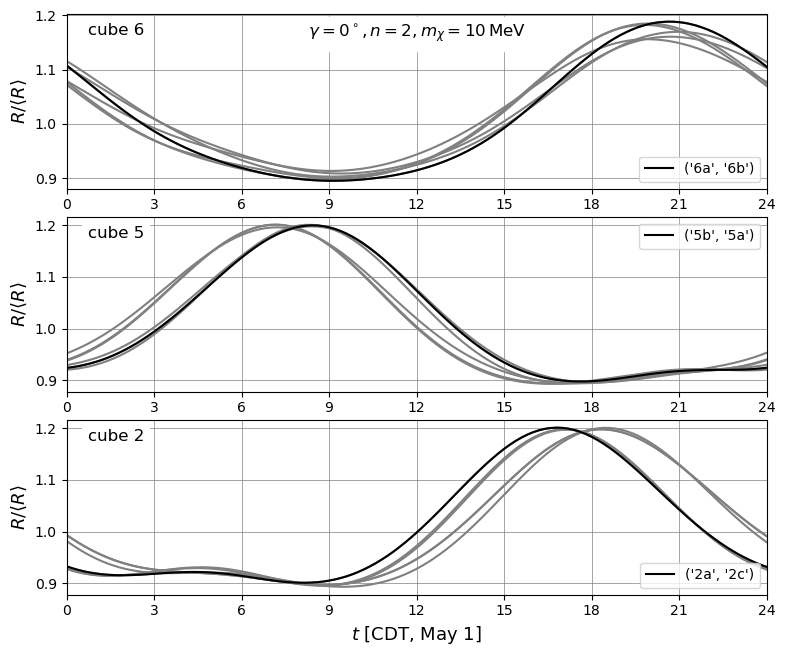

In [60]:
# Plot the selected cube orientations and compare geometry-uncertainty variations in R(t)

fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)
pp_ix = 0 # which cube version to use to define UP and FACE

makeCSV = True

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

# pA = p4  
pA = 1 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])

# For plotting: Gray curves show the variation across orthogonalized versions of the cube geometry
# Black curve shows the reference cube-basis version for the selected orientation
ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax2.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax2.plot(tH, RtHa, color='black', label=upfaceA)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

ax2.legend(loc='lower right')

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)



cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = 4 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax5.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax5.plot(tH, RtHa, color='black', label=upfaceA)

ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = 0 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax6.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax6.plot(tH, RtHa, color='black', label=upfaceA)


ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend(loc='lower right')

ax6.text(0.5, 0.95, r'$\gamma = {}^\circ, n = {}, m_\chi = {}$'.format(gammaD, n, mX) + r'$\,{\rm MeV}$', 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


plt.savefig('out/choices_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

### $\gamma = 45^\circ$ for $n = 0$ mediator model

In [61]:
# Compute R(t), fRMS, and score for each orientation, then store the top four UP/CCD choices

gamma = 45*deg 
n = 0
model = ('tot', n, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_uf = {}
phid_uf = {}
Rt_uf = {}
fRMS_uf = {}
score_uf = {}
best_uf = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
        thD = 180/np.pi * thE
        phD = 180/np.pi * phE
        thph_ix = (cube, pp, p)
        thetad_uf[thph_ix] = thD
        phid_uf[thph_ix] = phD
        RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
        Rt_uf[thph_ix] = np.array(RtH)
        fRMS_uf[thph_ix] = fRMS(RtH)
        score_uf[thph_ix] = chi2norm(RtH)
    scores = [score_uf[(cube, pp, p)] for p in range(len(UFs))]
    maxscore = np.max(scores)
    p_best = scores.index(maxscore)
    # from the others, select the second best:
    otherscores = scores[:p_best] + scores[p_best+1:]
    nextmax = np.max(otherscores)
    p_second = otherscores.index(nextmax)
    # ... and the third best
    thirdscores = otherscores[:p_second] + otherscores[p_second+1:]
    thirdmax = np.max(thirdscores)
    p_third = thirdscores.index(thirdmax)
    # ... etc
    fourscores = thirdscores[:p_third] + thirdscores[p_third+1:]
    fourmax = np.max(fourscores)
    p_four = fourscores.index(fourmax)
    # convert index from 'others' and 'third' to index of original 'scores'
    p_second += int(p_second >= p_best)
    p_third += int(p_third >= p_best)
    p_third += int(p_third >= p_second)
    p_four += int(p_four >= p_best)
    p_four += int(p_four >= p_second)
    p_four += int(p_four >= p_third)
    best_uf[orth_ix] = [p_best, p_second, p_third, p_four]
    print('{}:'.format(orth_ix), str(p_best)+':'+str(UFs[p_best]), 
                       str(p_second)+':'+str(UFs[p_second]), 
                       str(p_third)+':'+str(UFs[p_third]), 
                       str(p_four)+':'+str(UFs[p_four]), 
         )
        

(1, 0): 0:('a', 'b') 13:('-a', 'c') 16:('-b', 'a') 15:('-a', '-c')
(1, 1): 0:('a', 'b') 13:('-a', 'c') 18:('-b', '-a') 7:('b', '-c')
(1, 2): 5:('b', 'c') 12:('-a', 'b') 16:('-b', 'a') 3:('a', '-c')
(1, 3): 10:('c', '-a') 23:('-c', '-b') 16:('-b', 'a') 5:('b', 'c')
(1, 4): 0:('a', 'b') 13:('-a', 'c') 18:('-b', '-a') 7:('b', '-c')
(1, 5): 11:('c', '-b') 20:('-c', 'a') 9:('c', 'b') 22:('-c', '-a')
(1, 6): 12:('-a', 'b') 3:('a', '-c') 21:('-c', 'b') 8:('c', 'a')
(2, 0): 13:('-a', 'c') 0:('a', 'b') 18:('-b', '-a') 7:('b', '-c')
(2, 1): 11:('c', '-b') 20:('-c', 'a') 22:('-c', '-a') 0:('a', 'b')
(2, 2): 0:('a', 'b') 13:('-a', 'c') 7:('b', '-c') 18:('-b', '-a')
(2, 3): 0:('a', 'b') 13:('-a', 'c') 7:('b', '-c') 18:('-b', '-a')
(2, 4): 0:('a', 'b') 13:('-a', 'c') 7:('b', '-c') 11:('c', '-b')
(2, 5): 0:('a', 'b') 13:('-a', 'c') 21:('-c', 'b') 2:('a', '-b')
(2, 6): 11:('c', '-b') 20:('-c', 'a') 0:('a', 'b') 13:('-a', 'c')
(3, 0): 16:('-b', 'a') 5:('b', 'c') 14:('-a', '-b') 1:('a', 'c')
(3, 1): 4:(

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3455337375.py:147: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


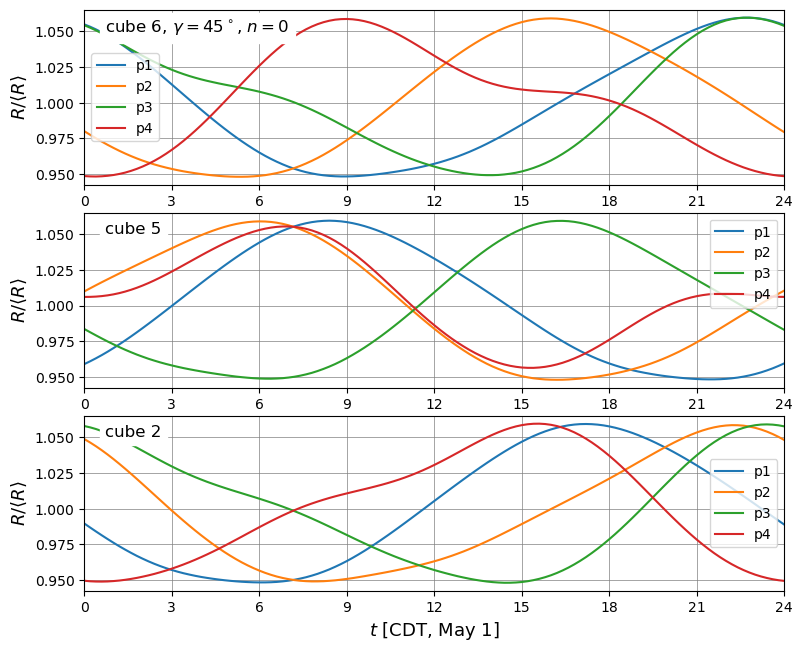

In [62]:
# Plot the top four candidate daily modulation curves for cubes 2, 5, and 6

fig = plt.figure(figsize=[2.0*unisize,unisize])
pp_ix = 0 # which cube version to use to define UP and FACE

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)
# p = best_uf[(cube, pp_ix)][1] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])
# fRMS_this 

# pA = p1 
# pB = p4

ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

### draw the cones:
# for pp in range(1, 7):
#     RtHa = Rt_uf[(cube, pp, pA)]
#     RtHb = Rt_uf[(cube, pp, pB)]
#     ax2.plot(tH, RtHa, color='gray')
#     ax2.plot(tH, RtHb, color='gray', linestyle='dashed')
RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
# ax2.plot(tH, RtH1, color='black', label=upface1)
# ax2.plot(tH, RtH2, color='black', linestyle='dashed', label=upface2)
ax2.plot(tH, RtH1, label='p1')
ax2.plot(tH, RtH2, label='p2')
ax2.plot(tH, RtH3, label='p3')
ax2.plot(tH, RtH4, label='p4')

# # mX, n label:
# ax2.text(0.2, 0.1, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
#          horizontalalignment='left',
#          verticalalignment='bottom', fontsize=12, 
#          color='black', 
#          backgroundcolor='white',
#          transform=ax2.transAxes, usetex=True)
# fRMS score:
gammaD = int(gamma*180/np.pi)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

# ax1.legend(loc=(0.25, 0.03))
# ax1.legend(loc=(0.4, 0.03))

# ax2.legend(ncol=5, loc=(0.2,0.84))
ax2.legend()


# Retrieve the four highest-scoring UP/CCD orientations for this cube
cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax5.plot(tH, RtH1, label='p1')
ax5.plot(tH, RtH2, label='p2')
ax5.plot(tH, RtH3, label='p3')
ax5.plot(tH, RtH4, label='p4')


ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

upface1 = (str(cube)+UFs[p1][0], str(cube)+UFs[p1][1])
upface2 = (str(cube)+UFs[p2][0], str(cube)+UFs[p2][1])
upface3 = (str(cube)+UFs[p3][0], str(cube)+UFs[p3][1])
upface4 = (str(cube)+UFs[p4][0], str(cube)+UFs[p4][1])

pA = p1 
pB = p4

# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

RtH1 = Rt_uf[(cube, 0, p1)]
RtH2 = Rt_uf[(cube, 0, p2)]
RtH3 = Rt_uf[(cube, 0, p3)]
RtH4 = Rt_uf[(cube, 0, p4)]
ax6.plot(tH, RtH1, label='p1')
ax6.plot(tH, RtH2, label='p2')
ax6.plot(tH, RtH3, label='p3')
ax6.plot(tH, RtH4, label='p4')


ax6.text(0.03, 0.95, r'cube {}, $\gamma = {}^\circ$, $n = {}$'.format(cube, gammaD, n), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend()


plt.savefig('out/options_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

Making selections for $\gamma = 45^\circ$, $n=0$:
* cube 2 always peaks in the evening: maybe pick a late one, like p2
* cube 6 has options p2 and p4 for mid-day peak. Pick p2, for larger amplitude
* cube 5 has a cool signal in p4.

These three choices are mutually out of phase, which is maximally desirable. 
* cube 2: 0:('a', 'b')
* cube 5: 18:('-b', '-a')
* cube 6: 0:('a', 'b')

/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3635565972.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


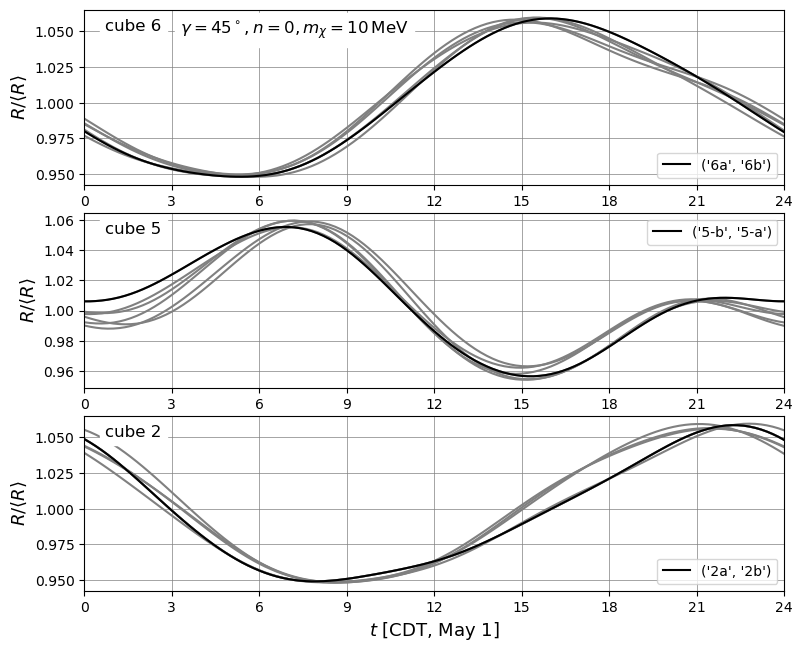

In [63]:
# Plot the selected cube orientations and compare geometry-uncertainty variations in R(t)

fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)
pp_ix = 0 # which cube version to use to define UP and FACE

makeCSV = False

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)
ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

pA = 0
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])

# For plotting: Gray curves show the variation across orthogonalized versions of the cube geometry
# Black curve shows the reference cube-basis version for the selected orientation
ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax2.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax2.plot(tH, RtHa, color='black', label=upfaceA)


ax2.legend(loc='lower right')

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)



cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)
ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)

pA = 18
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax5.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax5.plot(tH, RtHa, color='black', label=upfaceA)

ax5.legend()

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')
ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = 0
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax6.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax6.plot(tH, RtHa, color='black', label=upfaceA)


ax6.legend(loc='lower right')

ax6.text(0.3, 0.95, r'$\gamma = {}^\circ, n = {}, m_\chi = {}$'.format(gammaD, n, mX) + r'$\,{\rm MeV}$', 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


plt.savefig('out/choices_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

### $\gamma = 45^\circ$ for $n = 2$ mediator model

In [64]:
# Compute R(t), fRMS, and score for each orientation, then store the top four UP/CCD choices

gamma = 45*deg
n = 2
model = ('tot', n, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_uf = {}
phid_uf = {}
Rt_uf = {}
fRMS_uf = {}
score_uf = {}
best_uf = {}
for orth_ix in orth_ixs:
    cube, pp = orth_ix # cube label, orthogonalized label
    for p,uf in enumerate(UFs):
        # different choices for UP and FACE 
        l_up, l_face = uf 
        upvec = bases[(cube, pp, l_up)]
        facevec = bases[(cube, pp, l_face)]
        thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
        thD = 180/np.pi * thE
        phD = 180/np.pi * phE
        thph_ix = (cube, pp, p)
        thetad_uf[thph_ix] = thD
        phid_uf[thph_ix] = phD
        RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
        Rt_uf[thph_ix] = np.array(RtH)
        fRMS_uf[thph_ix] = fRMS(RtH)
        score_uf[thph_ix] = chi2norm(RtH)
    scores = [score_uf[(cube, pp, p)] for p in range(len(UFs))]
    maxscore = np.max(scores)
    p_best = scores.index(maxscore)
    # from the others, select the second best:
    otherscores = scores[:p_best] + scores[p_best+1:]
    nextmax = np.max(otherscores)
    p_second = otherscores.index(nextmax)
    # ... and the third best
    thirdscores = otherscores[:p_second] + otherscores[p_second+1:]
    thirdmax = np.max(thirdscores)
    p_third = thirdscores.index(thirdmax)
    # ... etc
    fourscores = thirdscores[:p_third] + thirdscores[p_third+1:]
    fourmax = np.max(fourscores)
    p_four = fourscores.index(fourmax)
    # convert index from 'others' and 'third' to index of original 'scores'
    p_second += int(p_second >= p_best)
    p_third += int(p_third >= p_best)
    p_third += int(p_third >= p_second)
    p_four += int(p_four >= p_best)
    p_four += int(p_four >= p_second)
    p_four += int(p_four >= p_third)
    best_uf[orth_ix] = [p_best, p_second, p_third, p_four]
    print('{}:'.format(orth_ix), str(p_best)+':'+str(UFs[p_best]), 
                       str(p_second)+':'+str(UFs[p_second]), 
                       str(p_third)+':'+str(UFs[p_third]), 
                       str(p_four)+':'+str(UFs[p_four]), 
         )
        

(1, 0): 11:('c', '-b') 16:('-b', 'a') 5:('b', 'c') 7:('b', '-c')
(1, 1): 21:('-c', 'b') 10:('c', '-a') 8:('c', 'a') 22:('-c', '-a')
(1, 2): 16:('-b', 'a') 5:('b', 'c') 18:('-b', '-a') 7:('b', '-c')
(1, 3): 12:('-a', 'b') 3:('a', '-c') 10:('c', '-a') 23:('-c', '-b')
(1, 4): 21:('-c', 'b') 6:('b', '-a') 8:('c', 'a') 17:('-b', 'c')
(1, 5): 20:('-c', 'a') 11:('c', '-b') 0:('a', 'b') 13:('-a', 'c')
(1, 6): 12:('-a', 'b') 16:('-b', 'a') 5:('b', 'c') 3:('a', '-c')
(2, 0): 6:('b', '-a') 15:('-a', '-c') 2:('a', '-b') 21:('-c', 'b')
(2, 1): 17:('-b', 'c') 21:('-c', 'b') 8:('c', 'a') 10:('c', '-a')
(2, 2): 10:('c', '-a') 21:('-c', 'b') 23:('-c', '-b') 8:('c', 'a')
(2, 3): 6:('b', '-a') 17:('-b', 'c') 2:('a', '-b') 15:('-a', '-c')
(2, 4): 2:('a', '-b') 15:('-a', '-c') 17:('-b', 'c') 0:('a', 'b')
(2, 5): 6:('b', '-a') 17:('-b', 'c') 2:('a', '-b') 21:('-c', 'b')
(2, 6): 6:('b', '-a') 17:('-b', 'c') 21:('-c', 'b') 8:('c', 'a')
(3, 0): 1:('a', 'c') 3:('a', '-c') 14:('-a', '-b') 12:('-a', 'b')
(3, 1): 

Making a selection for $\gamma = 45^\circ$ and $n=2$:
* what do the $n=0$ optimized selections look like?


/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/1739618242.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


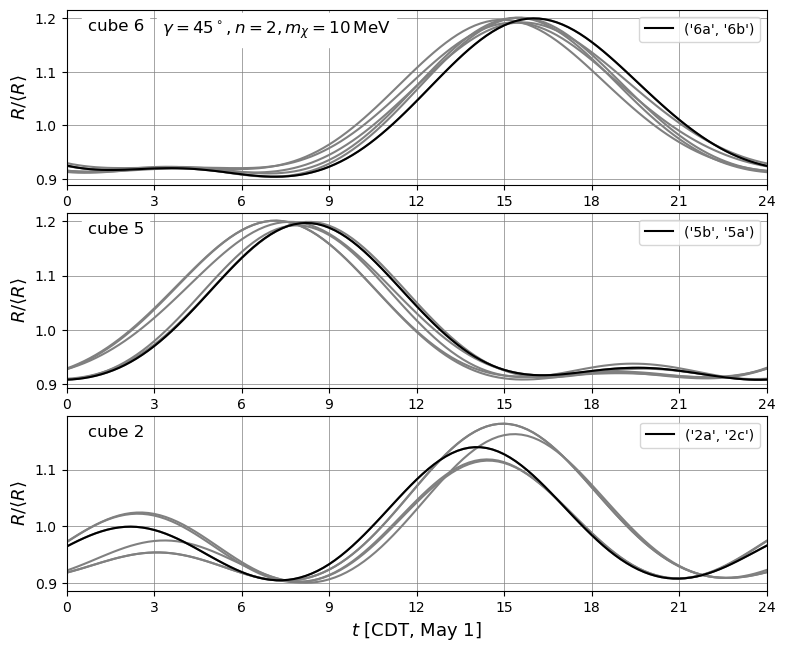

In [65]:
# Plot the selected cube orientations and compare geometry-uncertainty variations in R(t)

fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)
pp_ix = 0 # which cube version to use to define UP and FACE

makeCSV = False

cube = 2
ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

# pA = p4  
pA = 1 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])

# For plotting: Gray curves show the variation across orthogonalized versions of the cube geometry
# Black curve shows the reference cube-basis version for the selected orientation
ax2.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([0,24])
ax2.set_xticks([t for t in range(0, 25, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax2.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax2.plot(tH, RtHa, color='black', label=upfaceA)

ax2.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=False)

ax2.legend(loc='upper right')

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


cube = 5
ax5 = fig.add_axes([0,0.58,1,0.5], xscale='linear', yscale='linear')
p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = 4 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax5.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax5.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax5.set_xlim([0,24])
ax5.set_xticks([t for t in range(0, 25, 3)])
ax5.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax5.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax5.plot(tH, RtHa, color='black', label=upfaceA)

ax5.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax5.transAxes, usetex=False)
ax5.legend()

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


cube = 6
ax6 = fig.add_axes([0,1.16,1,0.5], xscale='linear', yscale='linear')

p1, p2, p3, p4 = best_uf[(cube, pp_ix)] # UP/FACE combination (cube_ix, pp_ix)

pA = 0 
upfaceA = (str(cube)+UFs[pA][0], str(cube)+UFs[pA][1])


# ax6.set_xlabel(r'$t$ [CDT, May 1]', fontsize=13, usetex=False)
ax6.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax6.set_xlim([0,24])
ax6.set_xticks([t for t in range(0, 25, 3)])
ax6.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for pp in range(1, 7):
    RtHa = Rt_uf[(cube, pp, pA)]
    ax6.plot(tH, RtHa, color='gray')
RtHa = Rt_uf[(cube, 0, pA)]
ax6.plot(tH, RtHa, color='black', label=upfaceA)


ax6.text(0.03, 0.95, r'cube {}'.format(cube), 
         horizontalalignment='left',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)
ax6.legend(loc='upper right')

ax6.text(0.3, 0.95, r'$\gamma = {}^\circ, n = {}, m_\chi = {}$'.format(gammaD, n, mX) + r'$\,{\rm MeV}$', 
         horizontalalignment='center',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax6.transAxes, usetex=False)

if makeCSV: 
    np.savetxt('out/RtH_{}_{}_g{}_n{}.csv'.format(upfaceA[0], upfaceA[1], gammaD, n), RtHa)


plt.savefig('out/choices_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

# Rates over the year

Using the selection for $\gamma = 0^\circ$:
* cube 6: p3 = 0:('a', 'b'), for late-evening maximum and interesting early-afternoon shoulder feature
* cube 5: p1 = 4:('b', 'a'), for maximum out-of-phase wrt cube 6
* cube 2: p2 = 1:('a', 'c'), for separation from cube 6

In [66]:
# Store the selected gamma=0 UP/CCD orientations for the three cubes (2, 5, 6)

upfaceG0 = {2:('a','c'), 5:('b','a'), 6:('a','b')}

In [67]:
"""Daily modulation for [ALL 2025] at [Fermilab]"""

cdt = dts.timezone(dts.timedelta(hours=-5), name='CDT')
midnight = dts.datetime(2025, 1, 1, hour=0, tzinfo=cdt)
midnight.astimezone(dts.timezone.utc)

nDays = 365

dt_per_hour = 5
dt_hours = 1/dt_per_hour
dt = dt_hours * dts.timedelta(hours=1)
obstimes = [midnight + dt * j for j in range(nDays*24*dt_per_hour+1)]
location = fermilab

tH = np.zeros(len(obstimes))
vEs = np.zeros(len(obstimes))
alts = np.zeros(len(obstimes))
azs = np.zeros(len(obstimes))

vE_ijk = []
for j,t in enumerate(obstimes):
    vE, alt, az = ethp.vE_AltAz(t, location)
    tH[j] = dt_hours*j 
    vEs[j] = vE
    alts[j] = alt
    azs[j] = az
    th0 = (90 - alt) * np.pi/180 
    ph0 = (-az) * np.pi/180 
    v_x = vE * np.sin(th0) * np.cos(ph0)
    v_y = vE * np.sin(th0) * np.sin(ph0)
    v_z = vE * np.cos(th0)
    vE_ijk += [[0, v_x, v_y, v_z]]
vE_ijk = qnc.array(vE_ijk)

print('altitude min and max [degrees]: {:.3f}, {:.3f}'.format( alts.min(), alts.max()))


altitude min and max [degrees]: -6.442, 89.948


In [68]:
# Save the full-year time grid to CSV

np.savetxt('out/tHyear.csv', tH)

## Make $R(t)$ plots for a given DM model

In [69]:
# Compute yearly R(t) curves for the selected cube orientations

gamma = 0 
n = 2
model = ('tot', n, 10) # (sI, n, mX)

rate_thphd = rn_intp[model]

thetad_yr = {}
phid_yr = {}
Rt_yr = {}
for cube,uf in upfaceG0.items():
    t0 = time.time()
    pp = 0 # use the 'black line' version of the cube geometry
    l_up, l_face = uf 
    upvec = bases[(cube, pp, l_up)]
    facevec = bases[(cube, pp, l_face)]
    thE, phE = thetaphi_cell(vE_ijk, upvec, facevec, gamma)
    thD = 180/np.pi * thE
    phD = 180/np.pi * phE
    thph_ix = cube # use cube=2,5,6 as the dict label
    thetad_yr[thph_ix] = thD
    phid_yr[thph_ix] = phD
    RtH = [rate_thphd([thD[i], phD[i]])[0] for i in range(len(thD))]
    Rt_yr[thph_ix] = np.array(RtH)
    print(cube, time.time() - t0)
        

2 1.1361210346221924
5 1.0563950538635254
6 1.164180040359497


/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/3437640043.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


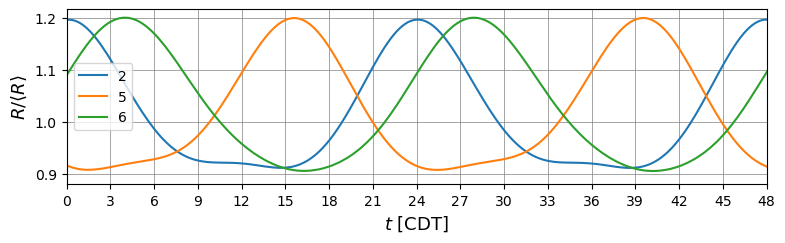

In [70]:
# Plot and optionally save the selected cubes' R(t) curves over the chosen year range

fig = plt.figure(figsize=[2.0*unisize,unisize])
gammaD = int(gamma*180/np.pi)

makeCSV = True

# Note: even though the full-year R(t) arrays are computed, the plots will show only a selected day range (e.g., May 1-2) for clarity
day_i = 0
day_f = 1

ax2 = fig.add_axes([0,0,1,0.5], xscale='linear', yscale='linear')

ax2.set_xlabel(r'$t$ [CDT]', fontsize=13, usetex=False)
ax2.set_ylabel(r'$R/\langle R \rangle$', fontsize=13, usetex=False)
ax2.set_xlim([24*day_i,24*(day_f+1)])
ax2.set_xticks([t for t in range(24*day_i, 24*(day_f+1)+1, 3)])
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

## draw the cones:
for cube in Rt_yr.keys():
    RtHa = Rt_yr[cube]
    if makeCSV:
        np.savetxt('out/RtH_g{}_n{}_cube{}.csv'.format(gammaD, n, cube), RtHa)
    ax2.plot(tH, RtHa, label=str(cube))

ax2.legend()

plt.savefig('out/year_n{}_g{}.pdf'.format(n, gammaD), 
            format="pdf", bbox_inches='tight')

fig.show()

## Additional Graph: Find the value of $\gamma$ that maximizes the sum of $f_{RMS}$ for all 6 cubes ##

**Addition made by Martha Yousif** 

Best gamma: 57 degrees
Maximum summed fRMS: 0.6561214158000205


/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/1495446340.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


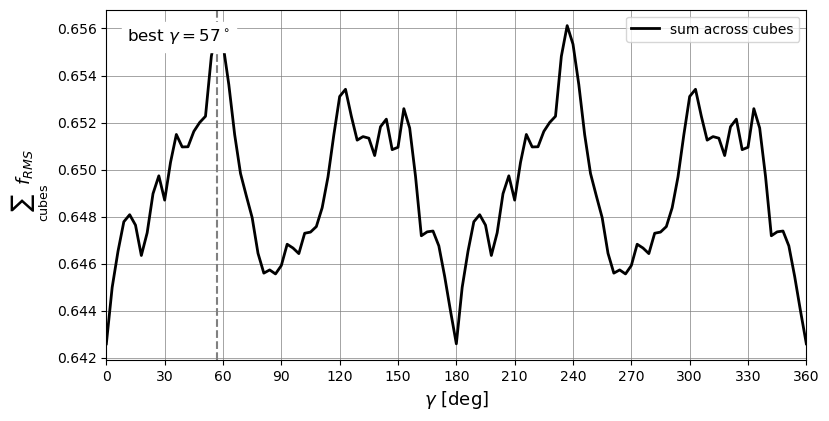

In [77]:
# Combine the best fRMS values across all six cubes to find the detector gamma
# that maximizes the total daily modulation.

pp = 0  # reference cube-basis version
cubes = range(1, 7)

# Stack each cube's best fRMS curve as a function of gamma.
fRMS_stack = np.array([np.array(fRMS_max[(cube, pp)]) for cube in cubes])

# Sum the best fRMS values across all six cubes.
fRMS_sum = np.sum(fRMS_stack, axis=0)

# Identify the gamma value where the summed fRMS is largest.
gix_best = np.argmax(fRMS_sum)
gamma_best = gammaDs[gix_best]

print("Best gamma:", gamma_best, "degrees")
print("Maximum summed fRMS:", fRMS_sum[gix_best])

# Plot only the summed fRMS curve.
fig = plt.figure(figsize=[2.0*unisize, unisize])
ax = fig.add_axes([0, 0, 1, 1], xscale='linear', yscale='linear')

ax.plot(gammaDs, fRMS_sum, color='black', linewidth=2, label='sum across cubes')
ax.axvline(gamma_best, linestyle='--', color='gray')

ax.set_xlabel(r'$\gamma$ [deg]', fontsize=13, usetex=False)
ax.set_ylabel(r'$\sum_{\mathrm{cubes}} f_{RMS}$', fontsize=13, usetex=False)
ax.set_xlim([0, 360])
ax.set_xticks([g for g in range(0, 361, 30)])
ax.grid(color='gray', linestyle='-', linewidth=0.5)

ax.text(
    0.03, 0.95,
    r'best $\gamma = {}^\circ$'.format(gamma_best),
    horizontalalignment='left',
    verticalalignment='top',
    fontsize=12,
    color='black',
    backgroundcolor='white',
    transform=ax.transAxes,
    usetex=False
)

ax.legend()

plt.savefig(
    'out/fRMS_all_cubes_pp{}_summed_gamma_scan.pdf'.format(pp),
    format="pdf",
    bbox_inches='tight'
)

fig.show()

In [80]:
# Check fRMS_sum values at gamma values separated by 90 degrees from the best gamma.

for g in [57, 147, 237, 327]:
    gix = gammaDs.index(g)
    print(g, fRMS_sum[gix])

57 0.6561214158000205
147 0.6508474459523016
237 0.6561214158000205
327 0.6508474459523016


In [81]:
# Print the top gamma values by summed fRMS.

top_ixs = np.argsort(fRMS_sum)[-12:][::-1]

for ix in top_ixs:
    print(gammaDs[ix], fRMS_sum[ix])

57 0.6561214158000205
237 0.6561214158000205
60 0.6553319237511117
240 0.6553319237511117
234 0.654813963369472
54 0.654813963369472
243 0.6536070760373813
63 0.6536070760373812
123 0.6534152676773479
303 0.6534152676773479
120 0.6531084541777615
300 0.6531084541777615


Best gamma: 57 degrees
Maximum summed fRMS: 0.6561214158000205
Average fRMS at best gamma: 0.10935356930000341


/var/folders/p3/wnl149_n5cq2mzyks06rhcrh0000gn/T/ipykernel_27811/892489414.py:62: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


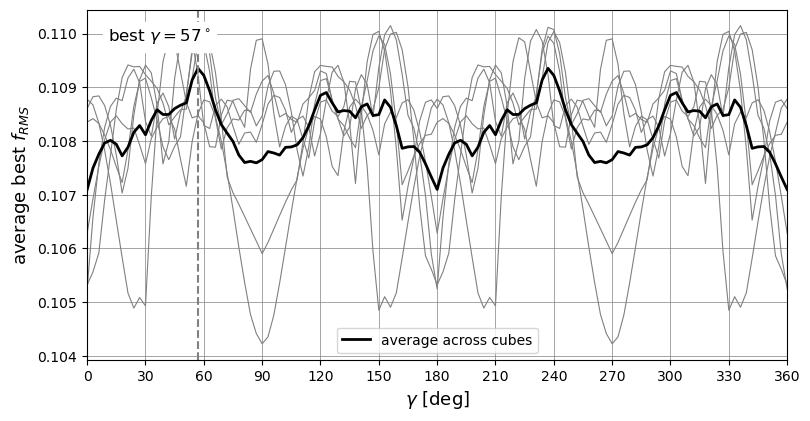

In [79]:
# Combine the best fRMS values across all six cubes to find the detector gamma that maximizes the total daily modulation.


pp = 0  # reference cube-basis version
cubes = range(1, 7)


# Stack each cube's best fRMS curve as a function of gamma.
fRMS_stack = np.array([np.array(fRMS_max[(cube, pp)]) for cube in cubes])


# Sum and average the best fRMS values across all six cubes.
# Maximizing the sum and maximizing the average gives the same best gamma.
fRMS_sum = np.sum(fRMS_stack, axis=0)
fRMS_avg = np.mean(fRMS_stack, axis=0)


# Identify the gamma value where the combined fRMS is largest.
gix_best = np.argmax(fRMS_sum)
gamma_best = gammaDs[gix_best]


print("Best gamma:", gamma_best, "degrees")
print("Maximum summed fRMS:", fRMS_sum[gix_best])
print("Average fRMS at best gamma:", fRMS_avg[gix_best])


# Plot individual cube contributions and the average across cubes.
fig = plt.figure(figsize=[2.0*unisize, unisize])
ax = fig.add_axes([0, 0, 1, 1], xscale='linear', yscale='linear')


for cube in cubes:
   ax.plot(gammaDs, fRMS_max[(cube, pp)], color='gray', linewidth=0.8)


ax.plot(gammaDs, fRMS_avg, color='black', linewidth=2, label='average across cubes')
ax.axvline(gamma_best, linestyle='--', color='gray')


ax.set_xlabel(r'$\gamma$ [deg]', fontsize=13, usetex=False)
ax.set_ylabel(r'average best $f_{RMS}$', fontsize=13, usetex=False)
ax.set_xlim([0, 360])
ax.set_xticks([g for g in range(0, 361, 30)])
ax.grid(color='gray', linestyle='-', linewidth=0.5)


ax.text(
   0.03, 0.95,
   r'best $\gamma = {}^\circ$'.format(gamma_best),
   horizontalalignment='left',
   verticalalignment='top',
   fontsize=12,
   color='black',
   backgroundcolor='white',
   transform=ax.transAxes,
   usetex=False
)


ax.legend()
fig.show()
